**Домашнее задание №5–6**

**Baseline-решение для задачи прогнозирования дефектов продукции**

**Цель**

Построить простое и честное baseline-решение для ML-задачи раннего прогнозирования дефекта продукции.

Задача модели — по производственным данным заранее оценить риск дефекта для каждой единицы продукции.

Дополнительно проверяется продуктовая часть задачи: можно ли по вероятностям модели прогнозировать дневной процент дефекта.

**Что делаем в ноутбуке**

1. Загружаем и очищаем данные.
2. Формируем бинарный таргет.
3. Проводим короткий EDA.
4. Делаем временное разбиение: train / validation / pretest / holdout.
5. Строим простые baseline.
6. Обучаем 1–2 простые модели.
7. Обучаем одну усложнённую модель.
8. Проводим простой AutoML-эксперимент.
9. Считаем ML-метрики.
10. Считаем совокупную метрику качества.
11. Прогнозируем дневной процент дефекта.
12. Делаем итоговый вывод.

**Важно**

Цель — получить простой, честный и проверяемый baseline.

---

**ВЫПОЛНЕНИЕ РАБОТЫ**

In [1]:
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

RANDOM_STATE = 42

DATA_PATH = "data.csv"

TIME_COL = "Дата-время производства"

TARGET_CANDIDATES = ["Карантины ПК | Неплоскостность | Стан 2000 | После стана"]

HOLDOUT_START = pd.Timestamp("2026-02-28 23:04:31")

TOP_K_SHARE = 0.10

# Фильтр по типу продукта.
PRODUCT_FILTER = "Лист г/к"

In [2]:
# Формулы для одинакового отображения

def print_title(text):
    print("\n" + "=" * 120)
    print(text)
    print("=" * 120)


def safe_display(df, n=20):
    display(df.head(n))

In [3]:
print_title("1. Загрузка данных")

df = pd.read_csv(
    DATA_PATH,
    compression="gzip",
    encoding="utf-8-sig",
    low_memory=False
    )

df = df.rename(columns={'Дата-время производства_y':'Дата-время производства'})

df.columns = [str(c).strip() for c in df.columns]

target_found = [c for c in TARGET_CANDIDATES if c in df.columns]
if not target_found:
    raise ValueError("Не найдена колонка таргета.")

TARGET_COL = target_found[0]

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

print("Исходный размер:", df.shape)
print("Колонка времени:", TIME_COL)
print("Колонка таргета:", TARGET_COL)
print("Минимальная дата:", df[TIME_COL].min())
print("Максимальная дата:", df[TIME_COL].max())


1. Загрузка данных
Исходный размер: (252608, 2919)
Колонка времени: Дата-время производства
Колонка таргета: Карантины ПК | Неплоскостность | Стан 2000 | После стана
Минимальная дата: 2025-06-01 00:00:31
Максимальная дата: 2026-04-30 23:02:56


In [6]:
print_title("2. Нормализация названий колонок после merge")


def _series_mismatch_share(a: pd.Series, b: pd.Series) -> float:
    """
    Доля несовпадений между двумя колонками.
    NaN == NaN считаем совпадением.
    """
    a = a.reset_index(drop=True)
    b = b.reset_index(drop=True)

    same = (a.eq(b)) | (a.isna() & b.isna())
    return float((~same).mean())


def normalize_merge_suffixes(
    df: pd.DataFrame,
    prefer=("", "_df1", "_df2", "_x", "_y"),
    verbose=True,
):
    """
    Убираем merge-суффиксы, которые образовывались во время сборки датасета.
    """
    df = df.copy()
    cols_before = list(df.columns)

    groups = {}
    for col in cols_before:
        s = str(col)
        m = re.search(r"(_df\d+|_[xy])$", s)

        if m:
            base = s[: -len(m.group(1))]
            suff = m.group(1)
        else:
            base = s
            suff = ""

        groups.setdefault(base, []).append((suff, s))

    keep_cols = []
    rename_map = {}
    conflict_rows = []

    for base, variants in groups.items():
        # Выбираем колонку по приоритету.
        chosen = None
        chosen_suff = None

        for p in prefer:
            found = next(((suff, c) for suff, c in variants if suff == p), None)
            if found is not None:
                chosen_suff, chosen = found
                break

        if chosen is None:
            chosen_suff, chosen = variants[0]

        keep_cols.append(chosen)

        if chosen != base:
            rename_map[chosen] = base

        # Если есть несколько вариантов одной колонки — проверяем, насколько они отличаются.
        if len(variants) > 1:
            for suff, other_col in variants:
                if other_col == chosen:
                    continue

                try:
                    mismatch = _series_mismatch_share(df[chosen], df[other_col])
                except Exception:
                    mismatch = np.nan

                conflict_rows.append({
                    "base_feature": base,
                    "chosen_col": chosen,
                    "chosen_suffix": chosen_suff,
                    "other_col": other_col,
                    "other_suffix": suff,
                    "mismatch_share": mismatch,
                    "chosen_notna": float(df[chosen].notna().mean()),
                    "other_notna": float(df[other_col].notna().mean()),
                })

    df2 = df[keep_cols].rename(columns=rename_map)

    # Страховка от дублей после rename.
    duplicated_after = pd.Series(df2.columns)[pd.Series(df2.columns).duplicated()].tolist()
    if len(duplicated_after) > 0:
        print("ВНИМАНИЕ: после нормализации появились дубли колонок.")
        display(pd.DataFrame({"duplicated_after_normalize": duplicated_after}).head(30))
        df2 = df2.loc[:, ~df2.columns.duplicated()]

    conflict_report = (
        pd.DataFrame(conflict_rows)
        .sort_values(["mismatch_share", "base_feature"], ascending=[False, True])
        .reset_index(drop=True)
        if len(conflict_rows) > 0
        else pd.DataFrame()
    )

    if verbose:
        print("Колонок до:", len(cols_before))
        print("Колонок после:", df2.shape[1])
        print("Переименовано:", len(rename_map))
        print("Групп с merge-вариантами:", sum(len(v) > 1 for v in groups.values()))

        if len(conflict_report) > 0:
            print("\nТОП merge-конфликтов, где варианты колонок отличаются:")
            display(conflict_report.head(20))
        else:
            print("Merge-конфликтов не найдено.")

    return df2, conflict_report


df, MERGE_CONFLICT_REPORT = normalize_merge_suffixes(df)

print("Размер после нормализации:", df.shape)

if len(MERGE_CONFLICT_REPORT) > 0:
    high_merge_conflicts = MERGE_CONFLICT_REPORT[
        MERGE_CONFLICT_REPORT["mismatch_share"].fillna(0) > 0
    ].copy()

    print("Колонок с ненулевым расхождением между merge-вариантами:", len(high_merge_conflicts))
else:
    high_merge_conflicts = pd.DataFrame()


2. Нормализация названий колонок после merge
Колонок до: 2918
Колонок после: 2918
Переименовано: 0
Групп с merge-вариантами: 0
Merge-конфликтов не найдено.
Размер после нормализации: (252608, 2918)


In [7]:
print_title("3. Доменные фильтры и формирование таргета")

df_work = df.copy()
print(f'Размер до фильтров: {df_work.shape}')

# Базовые доменные фильтры из прошлого задания.
if "Следующий цех (ПЗ)" in df_work.columns:
    df_work = df_work[df_work["Следующий цех (ПЗ)"].astype(str).str.strip().eq("ЛПЦ-2")].copy()
    print(df_work.shape)

if "Конечный цех (ПЗ)" in df_work.columns:
    df_work = df_work[df_work["Конечный цех (ПЗ)"].astype(str).str.strip().eq("ЛПЦ-2")].copy()
    print(df_work.shape)

if "Внутреннее назначение ЛПЦ-2 (ПЗ)" in df_work.columns:
    exclude = ["ЦГП5", "ЦХП", "ЦХП650", "РШК5"]
    df_work = df_work[~df_work["Внутреннее назначение ЛПЦ-2 (ПЗ)"].isin(exclude)].copy()
    print(df_work.shape)

if PRODUCT_FILTER is not None and "Тип продукта (СЗ)" in df_work.columns:
    df_work = df_work[df_work["Тип продукта (СЗ)"].astype(str).str.strip().eq(PRODUCT_FILTER)].copy()
    print(df_work.shape)

# Убираем строки без времени.
df_work = df_work[df_work[TIME_COL].notna()].copy()

# Бинарный таргет:
# 1 = есть запись о карантине / дефекте
# 0 = записи нет
y_all = df_work[TARGET_COL].notna().astype("int8")

print("Размер после фильтров:", df_work.shape)
print("Доля дефекта:", round(float(y_all.mean()), 5))
print("Кол-во дефектов:", int(y_all.sum()))
print("Кол-во нормы:", int((1 - y_all).sum()))

target_balance = pd.DataFrame({
    "class": ["0 = нет дефекта", "1 = дефект"],
    "count": [(y_all == 0).sum(), (y_all == 1).sum()],
    "share": [(y_all == 0).mean(), (y_all == 1).mean()],
})

target_balance


3. Доменные фильтры и формирование таргета
Размер до фильтров: (252608, 2918)
(135242, 2918)
(118400, 2918)
(118400, 2918)
(26853, 2918)
Размер после фильтров: (26853, 2918)
Доля дефекта: 0.07046
Кол-во дефектов: 1892
Кол-во нормы: 24961


,class,count,share
0,0 = нет дефекта,24961,0.929542
1,1 = дефект,1892,0.070458


In [8]:
print_title("4. Удаление утечек и служебных колонок")

DROP_EXACT = [
    "Unnamed: 0",
    "Unnamed: 0.1",
    "Unnamed: 0.2",
    "Unnamed: 0.3",
    "Unnamed: 0.4",
    "Unnamed: 0.5",
    "ID Siemens",
    "ID УЕ MES",
    "ID ПЗ MES",
    "ID продукта",
    "ID продукта HRM",
    "ID продукта HRM_x",
    "ID продукта HRM_y",
    "ID планового заказа",
    "Маркировка УЕ",
    "Номер рулона",
    "Номер плавки",
    "Заказ",
    "Дата травления ЦТМ",
    "Дата/время производства",
    "Дата/время производства_x",
    "Дата/время производства_y",
    "Дата-время задержания",
    "Вес отгруженный",
    "Недогруз",
    "Следующий цех (ПЗ)",
    "Конечный цех (ПЗ)",
    "Внутреннее назначение ЛПЦ-2 (ПЗ)",
    "Агрегат резки",
    "Бригада порезки",
    "Агрегат ЦТМ",
    "Бригада травления",
    "Неплоскостность (с натяжением), сред",
    "Неплоскостность (без натяжения), сред",
    "Тсм, сред (факт)",
    "Ткп, сред (факт)",
    "Скорость смотки, мин",
    "Скорость смотки, макс",
    "Заправочная скорость смотки",
    "Назначение с прокатки",
    "Индекс поверхности (факт)",
    "Фактический план охлаждения (PM)",
    "Фактическая ширина продукта",
    "Фактическая толщина продукта",
    'predict_proba_thin',
    'predict_proba_wide',
    'unwashed_predict',
    'p_unwashed',
    'crumpled_predict',
    'uncrumpled_predict',
    'p_crumpled',
    'p_uncrumpled',
    'prediction',
    'threshold',
    'p_defect',
    'skip_reason',
    'is_eligible',
    'defect_name',
    'model_name',
    'primary_key'
]

POST_FACT_PREFIX = [
    "Карантины |",
    "Карантины ПК",
    "1-е решение |",
    "1-е решение|",
    "Отсортировка |",
]

LEAK_KEYWORDS = [
    "карантин",
    "автокарантин",
    "дефект",
    "группа дефекта",
    "решение",
    "отсортировка",
    "предсказание",
    "модель",
    "коэффициент пораженности",
    "индекс поверхности",
    "рез. атт.",
    "дата-время задержания",
    "витков с отклонением",
    "мсо",
    "скн",
    "цтм",
]

ID_PATTERN = re.compile(
    r"(id\b|ID\b|рулон|плавк|заказ|парт|серия|coil|heat|slab|batch|order)",
    re.IGNORECASE,
)


def find_leakage_columns(columns, target_col, time_col):
    drop_cols = []

    for c in columns:
        c_str = str(c)
        c_low = c_str.lower()

        if c_str == time_col:
            continue

        if c_str == target_col:
            drop_cols.append(c_str)
            continue

        if c_str in DROP_EXACT:
            drop_cols.append(c_str)
            continue

        if any(c_low.startswith(p.lower()) for p in POST_FACT_PREFIX):
            drop_cols.append(c_str)
            continue

        if any(k.lower() in c_low for k in LEAK_KEYWORDS):
            drop_cols.append(c_str)
            continue

        if ID_PATTERN.search(c_str):
            drop_cols.append(c_str)
            continue

    return sorted(set(drop_cols))


leak_cols = find_leakage_columns(df_work.columns, TARGET_COL, TIME_COL)

df_feat = df_work.drop(columns=leak_cols, errors="ignore").copy()

print("Удалено колонок:", len(leak_cols))
print("Осталось колонок:", df_feat.shape[1])
print("Таргет остался в признаках:", TARGET_COL in df_feat.columns)
print("Время осталось в df_feat:", TIME_COL in df_feat.columns)

display(pd.DataFrame({"Удаленные колонки": leak_cols}).head(5))


4. Удаление утечек и служебных колонок
Удалено колонок: 2558
Осталось колонок: 360
Таргет остался в признаках: False
Время осталось в df_feat: True


,Удаленные колонки
0,1-е решение | ЛПЦ-2 | Автокарантин
1,1-е решение | ЛПЦ-2 | Группа дефекта
2,1-е решение | ЛПЦ-2 | Дата-время задержания
3,1-е решение | ЛПЦ-2 | Дефект
4,1-е решение | ЛПЦ-2 | Решение


In [9]:
print_title("5. Временное разделение train / validation / pretest / holdout")

order = df_feat.sort_values(TIME_COL, kind="mergesort").index

df_feat = df_feat.loc[order].reset_index(drop=True)
y_all = y_all.loc[order].reset_index(drop=True)

assert df_feat[TIME_COL].is_monotonic_increasing, "Данные не отсортированы по времени"
assert len(df_feat) == len(y_all), "df_feat и y имеют разную длину"

dev_mask = df_feat[TIME_COL] <= HOLDOUT_START
holdout_mask = df_feat[TIME_COL] > HOLDOUT_START

n = len(df_feat)
n_dev = int(dev_mask.sum())
n_holdout = int(holdout_mask.sum())

assert n_dev + n_holdout == n, "DEV + HOLDOUT не сходятся"
assert n_holdout > 0, "HOLDOUT пустой."

i1 = int(n_dev * 0.75)
i2 = int(n_dev * 0.90)

train_idx = slice(0, i1)
val_idx = slice(i1, i2)
pretest_idx = slice(i2, n_dev)
holdout_idx = slice(n_dev, n)


def split_report(name, idx):
    yy = y_all.iloc[idx]
    tt = df_feat[TIME_COL].iloc[idx]

    return {
        "split": name,
        "n": len(yy),
        "positive": int(yy.sum()),
        "negative": int((1 - yy).sum()),
        "positive_rate": float(yy.mean()),
        "time_min": tt.min(),
        "time_max": tt.max(),
    }


split_info = pd.DataFrame([
    split_report("TRAIN", train_idx),
    split_report("VALIDATION", val_idx),
    split_report("PRETEST", pretest_idx),
    split_report("HOLDOUT", holdout_idx),
])

display(split_info)

print("DEV макс. время:", df_feat[TIME_COL].iloc[:n_dev].max())
print("HOLDOUT мин. время:", df_feat[TIME_COL].iloc[n_dev:].min())


5. Временное разделение train / validation / pretest / holdout


,split,n,positive,negative,positive_rate,time_min,time_max
0,TRAIN,15954,1170,14784,0.073336,2025-06-01 02:29:15,2026-01-01 11:07:54
1,VALIDATION,3190,253,2937,0.079310,2026-01-01 11:09:37,2026-02-05 06:27:46
2,PRETEST,2128,179,1949,0.084117,2026-02-05 06:28:52,2026-02-28 23:04:31
3,HOLDOUT,5581,290,5291,0.051962,2026-02-28 23:08:13,2026-04-30 22:19:51


DEV макс. время: 2026-02-28 23:04:31
HOLDOUT мин. время: 2026-02-28 23:08:13



6. Короткий EDA
Размер рабочей выборки: (26853, 360)
Всего дефектов: 1892
Общая доля дефекта: 7.046 %


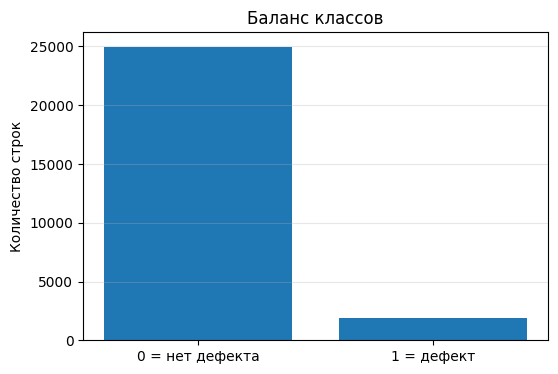

,month,n,defect_cnt,defect_rate
0,2025-06-01,2053,103,0.050170
1,2025-07-01,2179,146,0.067003
2,2025-08-01,2028,105,0.051775
3,2025-09-01,2425,215,0.088660
4,2025-10-01,3040,259,0.085197
5,2025-11-01,1577,135,0.085606
6,2025-12-01,2617,206,0.078716
7,2026-01-01,2906,241,0.082932
8,2026-02-01,2458,194,0.078926
9,2026-03-01,3075,165,0.053659


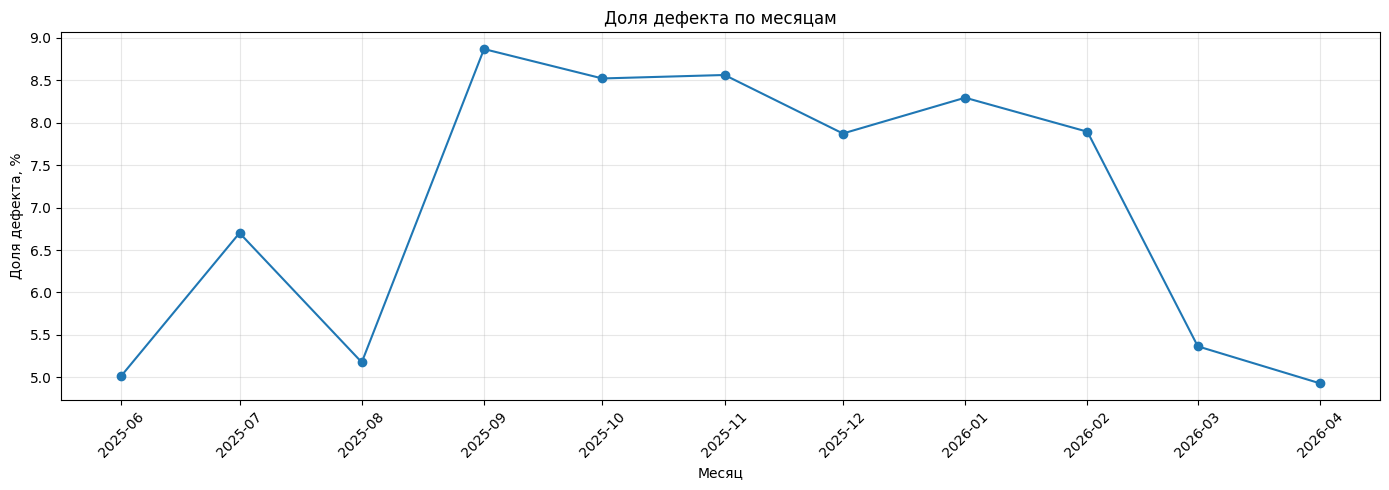

Топ признаков по доле пропусков:


,feature,missing_share
0,Границы КС | Длительность работы аргонной фурм...,1.0
1,Границы КС | Длительность разряжения на УВС_Зе...,1.0
2,Границы КС | Длительность разряжения на УВС_Зе...,1.0
3,Границы КС | Длительность работы аргонной фурм...,1.0
4,Химия | La,1.0
5,Химия | O,1.0
6,Границы ЛПЦ-2 | Скорость прокатки в последней ...,1.0
7,Границы ЛПЦ-2 | Скорость прокатки в последней ...,1.0
8,Границы КС | Факт. изменение расх. аргона в пр...,1.0
9,Границы КС | Факт. изменение расх. аргона в пр...,1.0


Количество константных признаков: 36


,Пример константных
0,Тип продукта
1,Тип продукции (код)
2,Тип продукта (СЗ)
3,Тип продукта (СЗ истор)
4,Химия | O
5,Химия | La
6,Химия | Pcm2
7,Химия | C+P
8,Химия | Cr+Cu+Mo
9,Химия | Cr+Cu+Mo+Ni


In [10]:
print_title("6. Короткий EDA")

print("Размер рабочей выборки:", df_feat.shape)
print("Всего дефектов:", int(y_all.sum()))
print("Общая доля дефекта:", round(float(y_all.mean() * 100), 3), "%")

# Баланс классов
plt.figure(figsize=(6, 4))
target_balance_plot = y_all.value_counts().sort_index()
plt.bar(["0 = нет дефекта", "1 = дефект"], target_balance_plot.values)
plt.title("Баланс классов")
plt.ylabel("Количество строк")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Доля дефекта по месяцам
eda_time = pd.DataFrame({
    "time": df_feat[TIME_COL],
    "y": y_all,
})
eda_time["month"] = eda_time["time"].dt.to_period("M").dt.to_timestamp()

monthly = (
    eda_time
    .groupby("month", as_index=False)
    .agg(
        n=("y", "size"),
        defect_cnt=("y", "sum"),
        defect_rate=("y", "mean"),
    )
)

display(monthly.tail(12))

plt.figure(figsize=(14, 5))
plt.plot(monthly["month"], monthly["defect_rate"] * 100, marker="o")
plt.title("Доля дефекта по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Доля дефекта, %")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Пропуски
missing = (
    df_feat
    .drop(columns=[TIME_COL], errors="ignore")
    .isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

missing.columns = ["feature", "missing_share"]

print("Топ признаков по доле пропусков:")
display(missing.head(20))

# Константные признаки
nunique = df_feat.drop(columns=[TIME_COL], errors="ignore").nunique(dropna=False)
constant_cols = nunique[nunique <= 1].index.tolist()

print("Количество константных признаков:", len(constant_cols))
display(pd.DataFrame({"Пример константных": constant_cols}).head(30))

**Краткий вывод EDA:**
- задача несбалансированная;
- Accuracy не подходит как основная метрика;
- нужна временная валидация;
- важны Precision, Recall, PR-AUC и Top-K метрики;
- дополнительно нужно проверить дневной прогноз процента дефекта.


In [11]:
print_title("7. Train подготовка признаков")

X_all = df_feat.drop(columns=[TIME_COL, TARGET_COL], errors="ignore").copy()
X_all = X_all.replace([np.inf, -np.inf], np.nan)

# Убираем datetime-колонки из признаков.
datetime_cols = list(X_all.select_dtypes(include=["datetime64[ns]", "datetimetz"]).columns)
X_all = X_all.drop(columns=datetime_cols, errors="ignore")

# Разделяем X/y.
X_train = X_all.iloc[train_idx].copy()
X_val = X_all.iloc[val_idx].copy()
X_pretest = X_all.iloc[pretest_idx].copy()
X_holdout = X_all.iloc[holdout_idx].copy()

y_train = y_all.iloc[train_idx].copy()
y_val = y_all.iloc[val_idx].copy()
y_pretest = y_all.iloc[pretest_idx].copy()
y_holdout = y_all.iloc[holdout_idx].copy()

print("До train очистки:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_pretest:", X_pretest.shape)
print("X_holdout:", X_holdout.shape)


7. Train подготовка признаков
До train очистки:
X_train: (15954, 359)
X_val: (3190, 359)
X_pretest: (2128, 359)
X_holdout: (5581, 359)


In [12]:
print_title("8. Простая очистка признаков")

MISS_TOKENS = {
    "", "nan", "none", "null", "na", "n/a",
    "__na__", "нет_данных", "нет данных", "None", "NA",
}

NA_TOKEN = "__NA__"


def fit_object_numeric_cast_rules(df_train, min_parse_rate=0.90, min_nunique=20):
    """
    На TRAIN определяем object-колонки, которые на самом деле являются числами.
    Новые признаки не создаём, только приводим тип.
    """
    cast_cols = []

    obj_cols = df_train.select_dtypes(include=["object"]).columns

    for c in obj_cols:
        s = df_train[c].astype(str).str.strip()
        s2 = s.str.replace(",", ".", regex=False)
        s2 = s2.where(~s2.str.lower().isin(MISS_TOKENS), np.nan)

        parsed = pd.to_numeric(s2, errors="coerce")

        denom = s2.notna().sum()
        parse_rate = parsed.notna().sum() / denom if denom > 0 else 0
        nunique = s.nunique(dropna=True)

        if parse_rate >= min_parse_rate and nunique >= min_nunique:
            cast_cols.append(c)

    return cast_cols


def apply_object_numeric_cast_rules(df_part, cast_cols):
    df_part = df_part.copy()

    for c in cast_cols:
        s = df_part[c].astype(str).str.strip()
        s = s.str.replace(",", ".", regex=False)
        s = s.where(~s.str.lower().isin(MISS_TOKENS), np.nan)
        df_part[c] = pd.to_numeric(s, errors="coerce")

    return df_part


# 1. object -> numeric только по правилам, обученным на TRAIN.
cast_cols = fit_object_numeric_cast_rules(X_train)

X_train = apply_object_numeric_cast_rules(X_train, cast_cols)
X_val = apply_object_numeric_cast_rules(X_val, cast_cols)
X_pretest = apply_object_numeric_cast_rules(X_pretest, cast_cols)
X_holdout = apply_object_numeric_cast_rules(X_holdout, cast_cols)

print("Object -> numeric колонок:", len(cast_cols))
display(pd.DataFrame({"cast_to_numeric": cast_cols}).head(30))

# 2. Удаляем почти пустые признаки. Решение только по TRAIN.
MAX_MISSING_SHARE = 0.90

missing_train = X_train.isna().mean()
drop_missing_cols = missing_train[missing_train > MAX_MISSING_SHARE].index.tolist()

X_train = X_train.drop(columns=drop_missing_cols, errors="ignore")
X_val = X_val.drop(columns=drop_missing_cols, errors="ignore")
X_pretest = X_pretest.drop(columns=drop_missing_cols, errors="ignore")
X_holdout = X_holdout.drop(columns=drop_missing_cols, errors="ignore")

print("Удалено почти пустых колонок:", len(drop_missing_cols))

# 3. Удаляем константные признаки. Решение только по TRAIN.
nunique_train = X_train.nunique(dropna=False)
drop_constant_cols = nunique_train[nunique_train <= 1].index.tolist()

X_train = X_train.drop(columns=drop_constant_cols, errors="ignore")
X_val = X_val.drop(columns=drop_constant_cols, errors="ignore")
X_pretest = X_pretest.drop(columns=drop_constant_cols, errors="ignore")
X_holdout = X_holdout.drop(columns=drop_constant_cols, errors="ignore")

print("Удалено константных колонок:", len(drop_constant_cols))

# 4. Удаляем слишком высококардинальные категориальные признаки.
# Это простая защита от ID колонок.
MAX_CAT_UNIQUE = 300

cat_cols_tmp = list(X_train.select_dtypes(include=["object", "category"]).columns)
high_card_cols = [
    c for c in cat_cols_tmp
    if X_train[c].nunique(dropna=True) > MAX_CAT_UNIQUE
]

X_train = X_train.drop(columns=high_card_cols, errors="ignore")
X_val = X_val.drop(columns=high_card_cols, errors="ignore")
X_pretest = X_pretest.drop(columns=high_card_cols, errors="ignore")
X_holdout = X_holdout.drop(columns=high_card_cols, errors="ignore")

print("Удалено high категориальных колонок:", len(high_card_cols))

# 5. Финальные списки числовых и категориальных колонок.
cat_cols = list(X_train.select_dtypes(include=["object", "category"]).columns)
num_cols = [c for c in X_train.columns if c not in cat_cols]

for c in cat_cols:
    X_train[c] = X_train[c].astype("object").where(X_train[c].notna(), NA_TOKEN).astype(str)
    X_val[c] = X_val[c].astype("object").where(X_val[c].notna(), NA_TOKEN).astype(str)
    X_pretest[c] = X_pretest[c].astype("object").where(X_pretest[c].notna(), NA_TOKEN).astype(str)
    X_holdout[c] = X_holdout[c].astype("object").where(X_holdout[c].notna(), NA_TOKEN).astype(str)

assert list(X_train.columns) == list(X_val.columns) == list(X_pretest.columns) == list(X_holdout.columns)

print("\nПосле очистки:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_pretest:", X_pretest.shape)
print("X_holdout:", X_holdout.shape)
print("Категориальных признаков:", len(cat_cols))
print("Числовых признаков:", len(num_cols))


8. Простая очистка признаков
Object -> numeric колонок: 2


,cast_to_numeric
0,Код грузополучателя (СЗ)
1,Код грузополучателя (СЗ истор)


Удалено почти пустых колонок: 69
Удалено константных колонок: 4
Удалено high категориальных колонок: 2

После очистки:
X_train: (15954, 284)
X_val: (3190, 284)
X_pretest: (2128, 284)
X_holdout: (5581, 284)
Категориальных признаков: 24
Числовых признаков: 260


In [13]:
print_title("9. Функции для ML-метрик")


def safe_average_precision(y_true, p):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(average_precision_score(y_true, p))


def safe_roc_auc(y_true, p):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(roc_auc_score(y_true, p))


def topk_metrics(y_true, p, top_k_share=0.10, eps=1e-12):
    """
    Top-K метрики для риск-очереди.

    Важная защита:
    если score у модели константный, то она не умеет ранжировать объекты.
    Поэтому для all-positive / all-negative / train-rate baseline
    не делаем вид, что top-k выбран осмысленно.
    В этом случае считаем expected random top-k:
    - precision_top ~= общая доля дефекта;
    - recall_top ~= top_k_share.

    Ранее расчитывал метрики не правильно - тут скорректировал
    """
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)

    n = len(y_true)
    k = max(1, int(n * top_k_share))

    total_pos = int(y_true.sum())
    base_rate = float(y_true.mean()) if n > 0 else 0.0

    valid_p = p[~np.isnan(p)]
    is_ranked = len(np.unique(np.round(valid_p, 12))) > 1

    if not is_ranked:
        expected_tp_top = float(k * base_rate)
        precision_top = base_rate
        recall_top = expected_tp_top / total_pos if total_pos > 0 else 0.0

        return {
            f"precision_top_{int(top_k_share * 100)}": float(precision_top),
            f"recall_top_{int(top_k_share * 100)}": float(recall_top),
            f"tp_top_{int(top_k_share * 100)}": float(expected_tp_top),
            f"n_top_{int(top_k_share * 100)}": int(k),
            "topk_mode": "constant_score_expected_random",
        }

    order = np.argsort(-p)
    top_idx = order[:k]
    y_top = y_true[top_idx]

    tp_top = int(y_top.sum())
    total_top = int(len(y_top))

    precision_top = tp_top / total_top if total_top > 0 else 0.0
    recall_top = tp_top / total_pos if total_pos > 0 else 0.0

    return {
        f"precision_top_{int(top_k_share * 100)}": float(precision_top),
        f"recall_top_{int(top_k_share * 100)}": float(recall_top),
        f"tp_top_{int(top_k_share * 100)}": float(tp_top),
        f"n_top_{int(top_k_share * 100)}": int(total_top),
        "topk_mode": "ranked_by_model_score",
    }


def calc_row_quality_score(metrics, top_k_share=0.10):
    """
    Внутренняя совокупная ML-метрика для row-level классификации.

    Важно:
    это НЕ полная бизнес-метрика.
    Она не включает дневной / недельный WMAE.
    Продуктовая полезность оценивается отдельно в блоке дневной агрегации.
    """
    top_p_col = f"precision_top_{int(top_k_share * 100)}"
    top_r_col = f"recall_top_{int(top_k_share * 100)}"

    pr_auc = metrics.get("pr_auc", 0.0)
    if pd.isna(pr_auc):
        pr_auc = 0.0

    return float(
        0.20 * metrics["precision"]
        + 0.20 * metrics["recall"]
        + 0.15 * metrics["f1"]
        + 0.15 * metrics[top_p_col]
        + 0.15 * metrics[top_r_col]
        + 0.15 * pr_auc
    )


def evaluate_at_threshold(y_true, p, thr, top_k_share=0.10):
    y_true = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)

    y_pred = (p >= thr).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    flagged_share = float(y_pred.mean())

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    top = topk_metrics(y_true, p, top_k_share=top_k_share)

    pr_auc = safe_average_precision(y_true, p)
    roc_auc = safe_roc_auc(y_true, p)

    metrics = {
        "thr": float(thr),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "flagged_share": flagged_share,
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        **top,
    }

    row_quality_score = calc_row_quality_score(metrics, top_k_share=top_k_share)

    metrics["row_quality_score"] = float(row_quality_score)
    metrics["quality_score"] = float(row_quality_score)

    return metrics


def threshold_table(y_true, p):
    p = np.asarray(p).astype(float)

    grid = np.unique(np.concatenate([
        np.array([0.0, 0.001, 0.005, 0.01]),
        np.quantile(p, np.linspace(0, 1, 101)),
        np.linspace(0.05, 0.95, 19),
        np.array([0.99, 1.0, 1.01]),
    ]))

    rows = []

    for thr in grid:
        m = evaluate_at_threshold(y_true, p, thr, top_k_share=TOP_K_SHARE)

        # Метрика выбора порога на validation.
        # Это именно ML-режим risk queue, а не прогноз дневного процента.
        #
        # Небольшой штраф за слишком большую долю флагов:
        # если модель помечает слишком много продукции, это ухудшает практическую применимость.
        flagged_penalty = max(0.0, m["flagged_share"] - 0.35)

        m["threshold_score"] = (
            0.35 * m["f1"]
            + 0.30 * m["precision"]
            + 0.25 * m["recall"]
            + 0.10 * m[f"precision_top_{int(TOP_K_SHARE * 100)}"]
            - 0.10 * flagged_penalty
        )

        rows.append(m)

    return pd.DataFrame(rows)


def pick_best_threshold_on_val(y_val, p_val):
    tbl = threshold_table(y_val, p_val)

    best = (
        tbl
        .sort_values(
            ["threshold_score", "precision", "recall", "flagged_share"],
            ascending=[False, False, False, True],
        )
        .iloc[0]
    )

    return float(best["thr"]), tbl


print("Метрики готовы.")


9. Функции для ML-метрик
Метрики готовы.


In [ ]:
print_title("10. Baseline-модели")

predictions = {}

train_rate = float(y_train.mean())
val_rate = float(y_val.mean())

rng = np.random.RandomState(RANDOM_STATE)

# 1. Наивный baseline:
# считаем, что все объекты относятся к отрицательному классу.
predictions["baseline_all_negative"] = {
    "type": "baseline",
    "fixed_thr": 1.1,
    "p_val": np.zeros(len(y_val)),
    "p_pretest": np.zeros(len(y_pretest)),
    "p_holdout": np.zeros(len(y_holdout)),
}

# 2. Вероятностный baseline:
# для каждого объекта прогнозируем частоту дефекта, рассчитанную только на TRAIN.
predictions["baseline_train_rate"] = {
    "type": "baseline",
    "fixed_thr": 0.5,
    "p_val": np.full(len(y_val), train_rate),
    "p_pretest": np.full(len(y_pretest), train_rate),
    "p_holdout": np.full(len(y_holdout), train_rate),
}

# 3. Случайный baseline для проверки качества ранжирования.
predictions["baseline_random"] = {
    "type": "baseline",
    "fixed_thr": None,
    "p_val": rng.random(len(y_val)),
    "p_pretest": rng.random(len(y_pretest)),
    "p_holdout": rng.random(len(y_holdout)),
}

print("TRAIN defect rate:", train_rate)
print("VAL defect rate:", val_rate)
print("Baseline-модели готовы.")

In [15]:
print_title("11. Препроцессор для простых sklearn-моделей")

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=NA_TOKEN)),
    ("onehot", ohe),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

print("Препроцессор готов.")
print("num_cols:", len(num_cols))
print("cat_cols:", len(cat_cols))


11. Препроцессор для простых sklearn-моделей
Препроцессор готов.
num_cols: 260
cat_cols: 24


In [16]:
print_title("12. Простая модель №1: Logistic Regression")

logreg_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

logreg_model.fit(X_train, y_train)

predictions["model_logistic_regression"] = {
    "type": "simple_model",
    "fixed_thr": None,
    "p_val": logreg_model.predict_proba(X_val)[:, 1],
    "p_pretest": logreg_model.predict_proba(X_pretest)[:, 1],
    "p_holdout": logreg_model.predict_proba(X_holdout)[:, 1],
}

print("Logistic Regression обучена.")


12. Простая модель №1: Logistic Regression
Logistic Regression обучена.


In [17]:
print_title("13. Простая модель №2: Decision Tree")

tree_model = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

tree_model.fit(X_train, y_train)

predictions["model_decision_tree"] = {
    "type": "simple_model",
    "fixed_thr": None,
    "p_val": tree_model.predict_proba(X_val)[:, 1],
    "p_pretest": tree_model.predict_proba(X_pretest)[:, 1],
    "p_holdout": tree_model.predict_proba(X_holdout)[:, 1],
}

print("Decision Tree обучена.")


13. Простая модель №2: Decision Tree
Decision Tree обучена.


In [18]:
print_title("14. Усложнённая модель: CatBoost")

import numpy as np
import pandas as pd

from sklearn.metrics import average_precision_score, roc_auc_score
from catboost import CatBoostClassifier


def safe_auc(y_true, p):
    try:
        return roc_auc_score(y_true, p)
    except Exception:
        return np.nan


def add_model_to_predictions(model_name, model_type, p_val, p_pretest, p_holdout):
    predictions[model_name] = {
        "type": model_type,
        "fixed_thr": None,
        "p_val": p_val,
        "p_pretest": p_pretest,
        "p_holdout": p_holdout,
    }


# Категориальные признаки для CatBoost
cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

catboost_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=10,
    random_seed=RANDOM_STATE,
    verbose=200,
    od_type="Iter",
    od_wait=100,
)

# Early stopping делаем только внутри TRAIN,
# чтобы не использовать VALIDATION для обучения модели.
cb_i = int(len(X_train) * 0.85)

X_tr_fit = X_train.iloc[:cb_i].copy()
y_tr_fit = y_train.iloc[:cb_i].copy()

X_tr_es = X_train.iloc[cb_i:].copy()
y_tr_es = y_train.iloc[cb_i:].copy()

print("CatBoost train part:", X_tr_fit.shape)
print("CatBoost early stopping part:", X_tr_es.shape)

catboost_model.fit(
    X_tr_fit,
    y_tr_fit,
    cat_features=cat_idx,
    eval_set=(X_tr_es, y_tr_es),
    use_best_model=True,
)

# Предсказания только на внешних сплитах
p_val_cb = catboost_model.predict_proba(X_val)[:, 1]
p_pretest_cb = catboost_model.predict_proba(X_pretest)[:, 1]
p_holdout_cb = catboost_model.predict_proba(X_holdout)[:, 1]

add_model_to_predictions(
    model_name="model_catboost_base",
    model_type="complex_model",
    p_val=p_val_cb,
    p_pretest=p_pretest_cb,
    p_holdout=p_holdout_cb,
)

ap_cb = average_precision_score(y_val, p_val_cb)
auc_cb = safe_auc(y_val, p_val_cb)

complex_model_name = "model_catboost_base"
complex_model = catboost_model

print("\nCatBoost обучен.")
print(f"CatBoost VAL PR-AUC:  {ap_cb:.5f}")
print(f"CatBoost VAL ROC-AUC: {auc_cb:.5f}")

print("\nУсложнённая модель добавлена в predictions как:", complex_model_name)
print("Средняя вероятность на VAL:", round(float(np.mean(p_val_cb)), 5))
print("Фактическая доля дефекта на VAL:", round(float(np.mean(y_val)), 5))


14. Усложнённая модель: CatBoost
CatBoost train part: (13560, 284)
CatBoost early stopping part: (2394, 284)
0:	test: 0.6996908	best: 0.6996908 (0)	total: 285ms	remaining: 4m 45s
200:	test: 0.8529041	best: 0.8544655 (181)	total: 18s	remaining: 1m 11s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8544654719
bestIteration = 181

Shrink model to first 182 iterations.

CatBoost обучен.
CatBoost VAL PR-AUC:  0.30788
CatBoost VAL ROC-AUC: 0.85526

Усложнённая модель добавлена в predictions как: model_catboost_base
Средняя вероятность на VAL: 0.07222
Фактическая доля дефекта на VAL: 0.07931


In [19]:
print_title("15. AutoML-эксперимент: FLAML")

import numpy as np
import pandas as pd

from flaml import AutoML
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.utils.class_weight import compute_sample_weight

# AutoML используется только как дополнительный эксперимент.
# Внешние VALIDATION / PRETEST / HOLDOUT не используются для обучения AutoML.
# Внутри TRAIN дополнительно делаем временной inner split:
# - первые 85% TRAIN: обучение AutoML;
# - последние 15% TRAIN: внутренняя проверка AutoML.

automl_cat_cols = [c for c in X_train.columns if str(X_train[c].dtype) in ("object", "category")]
automl_num_cols = [c for c in X_train.columns if c not in automl_cat_cols]

automl_numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

automl_categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )),
])

automl_preprocessor = ColumnTransformer(
    transformers=[
        ("num", automl_numeric_pipe, automl_num_cols),
        ("cat", automl_categorical_pipe, automl_cat_cols),
    ],
    remainder="drop",
)

# Внутреннее временное разделение только внутри TRAIN.
auto_i = int(len(X_train) * 0.85)

X_auto_fit_raw = X_train.iloc[:auto_i].copy()
y_auto_fit = y_train.iloc[:auto_i].astype(int).copy()

X_auto_es_raw = X_train.iloc[auto_i:].copy()
y_auto_es = y_train.iloc[auto_i:].astype(int).copy()

print("AutoML inner train:", X_auto_fit_raw.shape)
print("AutoML inner validation:", X_auto_es_raw.shape)

# Препроцессор обучаем только на inner train.
X_auto_fit_arr = automl_preprocessor.fit_transform(X_auto_fit_raw)
X_auto_es_arr = automl_preprocessor.transform(X_auto_es_raw)

# Внешние сплиты только transform.
X_val_auto_arr = automl_preprocessor.transform(X_val)
X_pretest_auto_arr = automl_preprocessor.transform(X_pretest)
X_holdout_auto_arr = automl_preprocessor.transform(X_holdout)

# На всякий случай переводим в плотный формат, если матрица sparse.
def to_dense_if_needed(x):
    return x.toarray() if hasattr(x, "toarray") else x

X_auto_fit_arr = to_dense_if_needed(X_auto_fit_arr)
X_auto_es_arr = to_dense_if_needed(X_auto_es_arr)
X_val_auto_arr = to_dense_if_needed(X_val_auto_arr)
X_pretest_auto_arr = to_dense_if_needed(X_pretest_auto_arr)
X_holdout_auto_arr = to_dense_if_needed(X_holdout_auto_arr)

safe_feature_names = [
    f"f_{i:05d}" for i in range(X_auto_fit_arr.shape[1])
]

X_auto_fit = pd.DataFrame(X_auto_fit_arr, columns=safe_feature_names)
X_auto_es = pd.DataFrame(X_auto_es_arr, columns=safe_feature_names)

X_val_auto = pd.DataFrame(X_val_auto_arr, columns=safe_feature_names)
X_pretest_auto = pd.DataFrame(X_pretest_auto_arr, columns=safe_feature_names)
X_holdout_auto = pd.DataFrame(X_holdout_auto_arr, columns=safe_feature_names)

sample_weight_fit = compute_sample_weight(
    class_weight="balanced",
    y=y_auto_fit,
)

sample_weight_es = compute_sample_weight(
    class_weight="balanced",
    y=y_auto_es,
)

print("FLAML input:")
print("X_auto_fit:", X_auto_fit.shape)
print("X_auto_es:", X_auto_es.shape)
print("X_val_auto:", X_val_auto.shape)
print("X_pretest_auto:", X_pretest_auto.shape)
print("X_holdout_auto:", X_holdout_auto.shape)
print("inner train positive rate:", round(float(y_auto_fit.mean()), 5))
print("inner validation positive rate:", round(float(y_auto_es.mean()), 5))


def flaml_pr_auc_metric(
    X_val,
    y_val,
    estimator,
    labels,
    X_train,
    y_train,
    weight_val=None,
    weight_train=None,
    config=None,
    groups_val=None,
    groups_train=None,
):
    p_val_local = estimator.predict_proba(X_val)[:, 1]

    if len(np.unique(y_val)) < 2:
        ap_val = 0.0
    else:
        ap_val = average_precision_score(
            y_val,
            p_val_local,
            sample_weight=weight_val,
        )

    loss = 1.0 - ap_val

    return loss, {
        "pr_auc": ap_val,
        "loss": loss,
    }


automl_model = AutoML()

automl_model.fit(
    X_train=X_auto_fit,
    y_train=y_auto_fit,
    X_val=X_auto_es,
    y_val=y_auto_es,
    task="classification",
    metric=flaml_pr_auc_metric,
    sample_weight=sample_weight_fit,
    sample_weight_val=sample_weight_es,
    time_budget=180,
    seed=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    log_file_name="flaml_defect_automl.log",
)

# Предсказания только на внешних сплитах.
p_val_auto = automl_model.predict_proba(X_val_auto)[:, 1]
p_pretest_auto = automl_model.predict_proba(X_pretest_auto)[:, 1]
p_holdout_auto = automl_model.predict_proba(X_holdout_auto)[:, 1]

automl_model_name = "model_automl_flaml"

predictions[automl_model_name] = {
    "type": "automl",
    "fixed_thr": None,
    "p_val": p_val_auto,
    "p_pretest": p_pretest_auto,
    "p_holdout": p_holdout_auto,
}

print("\nFLAML AutoML обучен.")
print("AutoML модель добавлена в predictions как:", automl_model_name)

print("\nЛучшая FLAML estimator:")
print(automl_model.best_estimator)

print("\nЛучший loss FLAML:")
print(automl_model.best_loss)

print("\nПроверка AutoML на внешней VALIDATION:")
print("VAL PR-AUC:", round(safe_average_precision(y_val, p_val_auto), 5))
print("VAL ROC-AUC:", round(safe_roc_auc(y_val, p_val_auto), 5))

print("\nВажно:")
print("- AutoML обучался только на inner train внутри TRAIN.")
print("- Inner validation тоже находится только внутри TRAIN.")
print("- VALIDATION / PRETEST / HOLDOUT не использовались для обучения AutoML.")

print("\nПроверка размеров предсказаний:")
print("p_val_auto:", p_val_auto.shape)
print("p_pretest_auto:", p_pretest_auto.shape)
print("p_holdout_auto:", p_holdout_auto.shape)


15. AutoML-эксперимент: FLAML
AutoML inner train: (13560, 284)
AutoML inner validation: (2394, 284)
FLAML input:
X_auto_fit: (13560, 284)
X_auto_es: (2394, 284)
X_val_auto: (3190, 284)
X_pretest_auto: (2128, 284)
X_holdout_auto: (5581, 284)
inner train positive rate: 0.0722
inner validation positive rate: 0.07978

FLAML AutoML обучен.
AutoML модель добавлена в predictions как: model_automl_flaml

Лучшая FLAML estimator:
rf

Лучший loss FLAML:
0.17214398102289297

Проверка AutoML на внешней VALIDATION:
VAL PR-AUC: 0.28569
VAL ROC-AUC: 0.85445

Важно:
- AutoML обучался только на inner train внутри TRAIN.
- Inner validation тоже находится только внутри TRAIN.
- VALIDATION / PRETEST / HOLDOUT не использовались для обучения AutoML.

Проверка размеров предсказаний:
p_val_auto: (3190,)
p_pretest_auto: (2128,)
p_holdout_auto: (5581,)


In [20]:
print_title("16. Подбор порогов на VALIDATION и оценка всех моделей")

eval_rows = []
threshold_tables = {}

for model_name, pack in predictions.items():
    p_val_model = pack["p_val"]

    # Для некоторых baseline порог заранее фиксированный.
    if pack.get("fixed_thr") is not None:
        best_thr_model = float(pack["fixed_thr"])
        threshold_tables[model_name] = None
    else:
        best_thr_model, tbl_model = pick_best_threshold_on_val(y_val, p_val_model)
        threshold_tables[model_name] = tbl_model

    predictions[model_name]["best_thr"] = best_thr_model

    for split_name, y_true, p_model in [
        ("VAL", y_val, pack["p_val"]),
        ("PRETEST", y_pretest, pack["p_pretest"]),
        ("HOLDOUT", y_holdout, pack["p_holdout"]),
    ]:
        metrics = evaluate_at_threshold(
            y_true=y_true,
            p=p_model,
            thr=best_thr_model,
            top_k_share=TOP_K_SHARE,
        )

        metrics["model_name"] = model_name
        metrics["model_type"] = pack["type"]
        metrics["split"] = split_name

        # Разделяем sanity baseline и рабочие baseline.
        if model_name in ["baseline_all_negative", "baseline_all_positive"]:
            metrics["baseline_role"] = "sanity_check"
        elif pack["type"] == "baseline":
            metrics["baseline_role"] = "working_baseline"
        else:
            metrics["baseline_role"] = "model"

        eval_rows.append(metrics)

eval_results = pd.DataFrame(eval_rows)

top_p_col = f"precision_top_{int(TOP_K_SHARE * 100)}"
top_r_col = f"recall_top_{int(TOP_K_SHARE * 100)}"
tp_top_col = f"tp_top_{int(TOP_K_SHARE * 100)}"
n_top_col = f"n_top_{int(TOP_K_SHARE * 100)}"

main_cols = [
    "model_name",
    "model_type",
    "baseline_role",
    "split",
    "thr",
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "roc_auc",
    "flagged_share",
    top_p_col,
    top_r_col,
    tp_top_col,
    n_top_col,
    "topk_mode",
    "tp",
    "fp",
    "fn",
    "tn",
    "row_quality_score",
    "quality_score",
]

print("Оценка всех моделей:")
display(
    eval_results[main_cols]
    .sort_values(["split", "quality_score"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\nПороги, выбранные на VALIDATION:")
threshold_summary = (
    eval_results[eval_results["split"] == "VAL"]
    [["model_name", "model_type", "baseline_role", "thr", "precision", "recall", "f1",
      "pr_auc", "flagged_share", top_p_col, top_r_col, "topk_mode", "row_quality_score"]]
    .sort_values("row_quality_score", ascending=False)
    .reset_index(drop=True)
)

display(threshold_summary)

print("\nПояснение:")
print("- row_quality_score / quality_score = совокупная row-level ML-метрика.")
print("- Это не полная продуктовая метрика дневного процента дефекта.")
print("- Продуктовая часть ниже оценивается отдельно через MAE/RMSE/BIAS/WMAE.")
print("- baseline_all_positive и baseline_all_negative — только sanity-check, не производственные решения.")


16. Подбор порогов на VALIDATION и оценка всех моделей
Оценка всех моделей:


,model_name,model_type,baseline_role,split,thr,precision,recall,f1,pr_auc,roc_auc,...,recall_top_10,tp_top_10,n_top_10,topk_mode,tp,fp,fn,tn,row_quality_score,quality_score
0,model_decision_tree,simple_model,model,HOLDOUT,0.178888,0.093047,0.941379,0.169355,0.149103,0.787361,...,0.379310,110.000000,558,ranked_by_model_score,273,2661,17,2630,0.341120,0.341120
1,model_catboost_base,complex_model,model,HOLDOUT,0.098148,0.152882,0.631034,0.246133,0.163123,0.820365,...,0.351724,102.000000,558,ranked_by_model_score,183,1014,107,4277,0.298350,0.298350
2,baseline_random,baseline,working_baseline,HOLDOUT,0.010000,0.051983,0.989655,0.098778,0.052818,0.503145,...,0.117241,34.000000,558,ranked_by_model_score,287,5234,3,57,0.257793,0.257793
3,baseline_all_positive,baseline,sanity_check,HOLDOUT,0.000000,0.051962,1.000000,0.098791,0.051962,0.500000,...,0.099982,28.994804,558,constant_score_expected_random,290,5291,0,0,0.255797,0.255797
4,model_logistic_regression,simple_model,model,HOLDOUT,0.045814,0.050462,0.941379,0.095789,0.066299,0.557667,...,0.137931,40.000000,558,ranked_by_model_score,273,5137,17,154,0.254124,0.254124
5,model_automl_flaml,automl,model,HOLDOUT,0.581369,0.166168,0.382759,0.231733,0.156692,0.805153,...,0.327586,95.000000,558,ranked_by_model_score,111,557,179,4734,0.242725,0.242725
6,baseline_all_negative,baseline,sanity_check,HOLDOUT,1.100000,0.000000,0.000000,0.000000,0.051962,0.500000,...,0.099982,28.994804,558,constant_score_expected_random,0,0,290,5291,0.030586,0.030586
7,baseline_train_rate,baseline,working_baseline,HOLDOUT,0.500000,0.000000,0.000000,0.000000,0.051962,0.500000,...,0.099982,28.994804,558,constant_score_expected_random,0,0,290,5291,0.030586,0.030586
8,model_catboost_base,complex_model,model,PRETEST,0.098148,0.211783,0.743017,0.329616,0.297595,0.838032,...,0.346369,62.000000,212,ranked_by_model_score,133,495,46,1454,0.380865,0.380865
9,model_decision_tree,simple_model,model,PRETEST,0.178888,0.144279,0.972067,0.251264,0.192238,0.782680,...,0.256983,46.000000,212,ranked_by_model_score,174,1032,5,917,0.360889,0.360889



Пороги, выбранные на VALIDATION:


,model_name,model_type,baseline_role,thr,precision,recall,f1,pr_auc,flagged_share,precision_top_10,recall_top_10,topk_mode,row_quality_score
0,model_catboost_base,complex_model,model,0.098148,0.234940,0.770751,0.360111,0.307877,0.260188,0.335423,0.422925,ranked_by_model_score,0.415088
1,model_automl_flaml,automl,model,0.581369,0.277429,0.699605,0.397306,0.285687,0.200000,0.304075,0.383399,ranked_by_model_score,0.400977
2,model_decision_tree,simple_model,model,0.178888,0.155365,0.932806,0.266366,0.206509,0.476176,0.235110,0.296443,ranked_by_model_score,0.368298
3,baseline_random,baseline,working_baseline,0.010000,0.080013,1.000000,0.148170,0.085904,0.991223,0.081505,0.102767,ranked_by_model_score,0.278754
4,baseline_all_positive,baseline,sanity_check,0.000000,0.079310,1.000000,0.146965,0.079310,1.000000,0.079310,0.100000,constant_score_expected_random,0.276700
5,model_logistic_regression,simple_model,model,0.045814,0.086147,0.988142,0.158479,0.080023,0.909718,0.040752,0.051383,ranked_by_model_score,0.264454
6,baseline_train_rate,baseline,working_baseline,0.500000,0.000000,0.000000,0.000000,0.079310,0.000000,0.079310,0.100000,constant_score_expected_random,0.038793
7,baseline_all_negative,baseline,sanity_check,1.100000,0.000000,0.000000,0.000000,0.079310,0.000000,0.079310,0.100000,constant_score_expected_random,0.038793



Пояснение:
- row_quality_score / quality_score = совокупная row-level ML-метрика.
- Это не полная продуктовая метрика дневного процента дефекта.
- Продуктовая часть ниже оценивается отдельно через MAE/RMSE/BIAS/WMAE.
- baseline_all_positive и baseline_all_negative — только sanity-check, не производственные решения.


In [ ]:
print_title("17. Сравнение моделей и выбор лучшей")

# Лучшую рабочую модель выбираем по VALIDATION.
#
# Важно:
# - all-negative baseline считаем наивным sanity-check;
# - рабочее сравнение делаем с применимыми baseline: train_rate / random;
# - HOLDOUT не используется для выбора модели.

SANITY_BASELINES = ["baseline_all_negative"]

val_compare = (
    eval_results[eval_results["split"] == "VAL"]
    .copy()
    .sort_values("row_quality_score", ascending=False)
    .reset_index(drop=True)
)

display(val_compare[main_cols])

# Лучший sanity baseline отдельно.
sanity_candidates = val_compare[val_compare["model_name"].isin(SANITY_BASELINES)].copy()

if len(sanity_candidates) > 0:
    best_sanity_baseline_row = (
        sanity_candidates
        .sort_values("row_quality_score", ascending=False)
        .iloc[0]
    )
else:
    best_sanity_baseline_row = None

# Лучший рабочий baseline отдельно.
working_baseline_candidates = val_compare[
    (val_compare["model_type"] == "baseline")
    & (~val_compare["model_name"].isin(SANITY_BASELINES))
].copy()

if len(working_baseline_candidates) > 0:
    best_working_baseline_row = (
        working_baseline_candidates
        .sort_values("row_quality_score", ascending=False)
        .iloc[0]
    )
else:
    best_working_baseline_row = None

# Лучшая ML-модель отдельно.
model_candidates = val_compare[val_compare["model_type"] != "baseline"].copy()

if len(model_candidates) == 0:
    raise ValueError("Не найдено ни одной ML-модели для выбора.")
else:
    best_model_row = model_candidates.sort_values("row_quality_score", ascending=False).iloc[0]

best_model_name = best_model_row["model_name"]
best_thr = float(best_model_row["thr"])

if best_sanity_baseline_row is not None:
    print("Лучший sanity baseline на VALIDATION:", best_sanity_baseline_row["model_name"])
    print("Sanity baseline row_quality_score:", round(float(best_sanity_baseline_row["row_quality_score"]), 5))
    print("Комментарий: sanity baseline нужен только для проверки крайних случаев метрик.")

if best_working_baseline_row is not None:
    print("\nЛучший рабочий baseline на VALIDATION:", best_working_baseline_row["model_name"])
    print("Working baseline row_quality_score:", round(float(best_working_baseline_row["row_quality_score"]), 5))

print("\nЛучшая ML-модель на VALIDATION:", best_model_name)
print("Тип модели:", best_model_row["model_type"])
print("Порог:", best_thr)
print("ML row_quality_score:", round(float(best_model_row["row_quality_score"]), 5))
print("Flagged share на VALIDATION:", round(float(best_model_row["flagged_share"]), 5))
print(f"Precision@Top-{int(TOP_K_SHARE * 100)}%:", round(float(best_model_row[top_p_col]), 5))
print(f"Recall@Top-{int(TOP_K_SHARE * 100)}%:", round(float(best_model_row[top_r_col]), 5))

if best_working_baseline_row is not None:
    if float(best_model_row["row_quality_score"]) > float(best_working_baseline_row["row_quality_score"]):
        print("\nВывод: ML-модель лучше рабочего baseline по row-level ML-метрике на VALIDATION.")
    else:
        print("\nВывод: ML-модель НЕ лучше рабочего baseline по row-level ML-метрике на VALIDATION.")
else:
    print("\nРабочий baseline не найден. Сравнение выполнено только с sanity baseline.")

# Сохраняем вероятности лучшей модели для следующих блоков.
p_val = predictions[best_model_name]["p_val"]
p_pretest = predictions[best_model_name]["p_pretest"]
p_holdout = predictions[best_model_name]["p_holdout"]

final_model_name = best_model_name

print("\nfinal_model_name:", final_model_name)
print("best_thr:", best_thr)


17. Сравнение моделей и выбор лучшей


,model_name,model_type,baseline_role,split,thr,precision,recall,f1,pr_auc,roc_auc,...,recall_top_10,tp_top_10,n_top_10,topk_mode,tp,fp,fn,tn,row_quality_score,quality_score
0,model_catboost_base,complex_model,model,VAL,0.098148,0.234940,0.770751,0.360111,0.307877,0.855258,...,0.422925,107.0,319,ranked_by_model_score,195,635,58,2302,0.415088,0.415088
1,model_automl_flaml,automl,model,VAL,0.581369,0.277429,0.699605,0.397306,0.285687,0.854447,...,0.383399,97.0,319,ranked_by_model_score,177,461,76,2476,0.400977,0.400977
2,model_decision_tree,simple_model,model,VAL,0.178888,0.155365,0.932806,0.266366,0.206509,0.809265,...,0.296443,75.0,319,ranked_by_model_score,236,1283,17,1654,0.368298,0.368298
3,baseline_random,baseline,working_baseline,VAL,0.010000,0.080013,1.000000,0.148170,0.085904,0.529168,...,0.102767,26.0,319,ranked_by_model_score,253,2909,0,28,0.278754,0.278754
4,baseline_all_positive,baseline,sanity_check,VAL,0.000000,0.079310,1.000000,0.146965,0.079310,0.500000,...,0.100000,25.3,319,constant_score_expected_random,253,2937,0,0,0.276700,0.276700
5,model_logistic_regression,simple_model,model,VAL,0.045814,0.086147,0.988142,0.158479,0.080023,0.537400,...,0.051383,13.0,319,ranked_by_model_score,250,2652,3,285,0.264454,0.264454
6,baseline_train_rate,baseline,working_baseline,VAL,0.500000,0.000000,0.000000,0.000000,0.079310,0.500000,...,0.100000,25.3,319,constant_score_expected_random,0,0,253,2937,0.038793,0.038793
7,baseline_all_negative,baseline,sanity_check,VAL,1.100000,0.000000,0.000000,0.000000,0.079310,0.500000,...,0.100000,25.3,319,constant_score_expected_random,0,0,253,2937,0.038793,0.038793


Лучший sanity baseline на VALIDATION: baseline_all_positive
Sanity baseline row_quality_score: 0.2767
Комментарий: sanity baseline нужен только для проверки крайних случаев метрик.

Лучший рабочий baseline на VALIDATION: baseline_random
Working baseline row_quality_score: 0.27875

Лучшая ML-модель на VALIDATION: model_catboost_base
Тип модели: complex_model
Порог: 0.09814751042413185
ML row_quality_score: 0.41509
Flagged share на VALIDATION: 0.26019
Precision@Top-10%: 0.33542
Recall@Top-10%: 0.42292

Вывод: ML-модель лучше рабочего baseline по row-level ML-метрике на VALIDATION.

final_model_name: model_catboost_base
best_thr: 0.09814751042413185


In [22]:
print_title("18. Top-K метрики")

# Top-K важен для производства:
# если можно проверить только ограниченную долю продукции,
# нужно понимать, сколько дефектов попадает в эту риск-зону.

topk_cols = [
    "model_name",
    "model_type",
    "baseline_role",
    "split",
    "pr_auc",
    "flagged_share",
    top_p_col,
    top_r_col,
    tp_top_col,
    n_top_col,
    "topk_mode",
    "row_quality_score",
]

topk_table = (
    eval_results[topk_cols]
    .sort_values(["split", top_r_col], ascending=[True, False])
    .reset_index(drop=True)
)

display(topk_table)

print(
    f"Top-{int(TOP_K_SHARE * 100)}% — это имитация ограниченной зоны дополнительной проверки продукции."
)

print("\nTop-K метрики выбранной финальной модели:")
final_topk_table = (
    eval_results[eval_results["model_name"] == final_model_name]
    [[
        "split",
        "model_name",
        "pr_auc",
        "precision",
        "recall",
        "flagged_share",
        top_p_col,
        top_r_col,
        tp_top_col,
        n_top_col,
        "topk_mode",
        "row_quality_score",
    ]]
    .sort_values("split")
    .reset_index(drop=True)
)

display(final_topk_table)

for _, r in final_topk_table.iterrows():
    print(
        f"{r['split']}: "
        f"Precision@Top-{int(TOP_K_SHARE * 100)}%={r[top_p_col]:.4f}, "
        f"Recall@Top-{int(TOP_K_SHARE * 100)}%={r[top_r_col]:.4f}, "
        f"TP@Top-{int(TOP_K_SHARE * 100)}%={r[tp_top_col]:.1f}, "
        f"N@Top-{int(TOP_K_SHARE * 100)}%={int(r[n_top_col])}, "
        f"mode={r['topk_mode']}"
    )


18. Top-K метрики


,model_name,model_type,baseline_role,split,pr_auc,flagged_share,precision_top_10,recall_top_10,tp_top_10,n_top_10,topk_mode,row_quality_score
0,model_decision_tree,simple_model,model,HOLDOUT,0.149103,0.525712,0.197133,0.379310,110.000000,558,ranked_by_model_score,0.341120
1,model_catboost_base,complex_model,model,HOLDOUT,0.163123,0.214478,0.182796,0.351724,102.000000,558,ranked_by_model_score,0.298350
2,model_automl_flaml,automl,model,HOLDOUT,0.156692,0.119692,0.170251,0.327586,95.000000,558,ranked_by_model_score,0.242725
3,model_logistic_regression,simple_model,model,HOLDOUT,0.066299,0.969360,0.071685,0.137931,40.000000,558,ranked_by_model_score,0.254124
4,baseline_random,baseline,working_baseline,HOLDOUT,0.052818,0.989249,0.060932,0.117241,34.000000,558,ranked_by_model_score,0.257793
5,baseline_all_negative,baseline,sanity_check,HOLDOUT,0.051962,0.000000,0.051962,0.099982,28.994804,558,constant_score_expected_random,0.030586
6,baseline_all_positive,baseline,sanity_check,HOLDOUT,0.051962,1.000000,0.051962,0.099982,28.994804,558,constant_score_expected_random,0.255797
7,baseline_train_rate,baseline,working_baseline,HOLDOUT,0.051962,0.000000,0.051962,0.099982,28.994804,558,constant_score_expected_random,0.030586
8,model_catboost_base,complex_model,model,PRETEST,0.297595,0.295113,0.292453,0.346369,62.000000,212,ranked_by_model_score,0.380865
9,model_automl_flaml,automl,model,PRETEST,0.213247,0.171053,0.240566,0.284916,51.000000,212,ranked_by_model_score,0.306104


Top-10% — это имитация ограниченной зоны дополнительной проверки продукции.

Top-K метрики выбранной финальной модели:


,split,model_name,pr_auc,precision,recall,flagged_share,precision_top_10,recall_top_10,tp_top_10,n_top_10,topk_mode,row_quality_score
0,HOLDOUT,model_catboost_base,0.163123,0.152882,0.631034,0.214478,0.182796,0.351724,102.0,558,ranked_by_model_score,0.298350
1,PRETEST,model_catboost_base,0.297595,0.211783,0.743017,0.295113,0.292453,0.346369,62.0,212,ranked_by_model_score,0.380865
2,VAL,model_catboost_base,0.307877,0.234940,0.770751,0.260188,0.335423,0.422925,107.0,319,ranked_by_model_score,0.415088


HOLDOUT: Precision@Top-10%=0.1828, Recall@Top-10%=0.3517, TP@Top-10%=102.0, N@Top-10%=558, mode=ranked_by_model_score
PRETEST: Precision@Top-10%=0.2925, Recall@Top-10%=0.3464, TP@Top-10%=62.0, N@Top-10%=212, mode=ranked_by_model_score
VAL: Precision@Top-10%=0.3354, Recall@Top-10%=0.4229, TP@Top-10%=107.0, N@Top-10%=319, mode=ranked_by_model_score


In [23]:
print_title("19. Прогноз дневного процента дефекта")

# Здесь переходим от row-level классификации к продуктовой задаче.
#
# Для дневного процента используем вероятности модели:
# - прогноз количества дефектов за день = `sum(p)`;
# - прогноз дневного процента дефекта = `mean(p)`;
# - threshold используется отдельно только для очереди контроля.


from sklearn.isotonic import IsotonicRegression

USE_CALIBRATION = True

print("Выбранная модель:", final_model_name)
print("Текущий дефект:", TARGET_COL)
print("Threshold для очереди контроля:", best_thr)
print("USE_CALIBRATION:", USE_CALIBRATION)

train_rate = float(np.asarray(y_train).mean())
val_rate = float(np.asarray(y_val).mean())

print("\nBaseline rates:")
print("TRAIN defect rate:", train_rate)
print("VAL defect rate:", val_rate)

# Калибровку обучаем только на VALIDATION.
# Поэтому calibrated-результат на VAL не считаем финально честным.
can_calibrate = (
    USE_CALIBRATION
    and len(np.unique(y_val)) == 2
    and len(np.unique(np.asarray(p_val).round(10))) > 1
)

if can_calibrate:
    calibrator = IsotonicRegression(out_of_bounds="clip")
    calibrator.fit(np.asarray(p_val, dtype=float), np.asarray(y_val).astype(int))

    p_val_cal = calibrator.predict(np.asarray(p_val, dtype=float))
    p_pretest_cal = calibrator.predict(np.asarray(p_pretest, dtype=float))
    p_holdout_cal = calibrator.predict(np.asarray(p_holdout, dtype=float))

    print("Калибровка вероятностей выполнена.")
else:
    p_val_cal = np.asarray(p_val, dtype=float)
    p_pretest_cal = np.asarray(p_pretest, dtype=float)
    p_holdout_cal = np.asarray(p_holdout, dtype=float)

    print("Калибровка не выполнена. Используем сырые вероятности.")

p_val_cal = np.clip(p_val_cal, 0, 1)
p_pretest_cal = np.clip(p_pretest_cal, 0, 1)
p_holdout_cal = np.clip(p_holdout_cal, 0, 1)


def make_score_frame(split_name, idx, y_split, p_raw, p_cal, thr, train_rate, val_rate):
    tmp = pd.DataFrame({
        "split": split_name,
        "time": pd.to_datetime(df_feat[TIME_COL].iloc[idx].values),
        "y": np.asarray(y_split).astype(int),
        "p_raw": np.asarray(p_raw).astype(float),
        "p_cal": np.asarray(p_cal).astype(float),
    })

    tmp["day"] = tmp["time"].dt.floor("D")
    tmp["week"] = tmp["time"].dt.to_period("W").dt.start_time

    # baseline-прогнозы дневного процента
    tmp["p_base_train_rate"] = float(train_rate)
    tmp["p_base_val_rate"] = float(val_rate)

    # threshold-режим — только для очереди контроля
    tmp["pred_thr"] = (tmp["p_raw"] >= thr).astype("int8")

    tmp["tp_thr"] = ((tmp["pred_thr"] == 1) & (tmp["y"] == 1)).astype("int8")
    tmp["fp_thr"] = ((tmp["pred_thr"] == 1) & (tmp["y"] == 0)).astype("int8")
    tmp["fn_thr"] = ((tmp["pred_thr"] == 0) & (tmp["y"] == 1)).astype("int8")

    return tmp


score_val = make_score_frame(
    "VAL",
    val_idx,
    y_val,
    p_val,
    p_val_cal,
    best_thr,
    train_rate,
    val_rate,
)

score_pretest = make_score_frame(
    "PRETEST",
    pretest_idx,
    y_pretest,
    p_pretest,
    p_pretest_cal,
    best_thr,
    train_rate,
    val_rate,
)

score_holdout = make_score_frame(
    "HOLDOUT",
    holdout_idx,
    y_holdout,
    p_holdout,
    p_holdout_cal,
    best_thr,
    train_rate,
    val_rate,
)

score_all = pd.concat(
    [score_val, score_pretest, score_holdout],
    axis=0,
    ignore_index=True,
)

print("score_all shape:", score_all.shape)
display(score_all.head())

split_summary = (
    score_all
    .groupby("split", as_index=False)
    .agg(
        n=("y", "size"),
        fact_rate=("y", "mean"),
        pred_raw_mean=("p_raw", "mean"),
        pred_cal_mean=("p_cal", "mean"),
        pred_base_train_mean=("p_base_train_rate", "mean"),
        pred_base_val_mean=("p_base_val_rate", "mean"),
        flagged_share=("pred_thr", "mean"),
        fact_cnt=("y", "sum"),
        pred_raw_cnt=("p_raw", "sum"),
        pred_cal_cnt=("p_cal", "sum"),
    )
)

print("\nПроверка средних вероятностей и факта по split:")
display(split_summary)


19. Прогноз дневного процента дефекта
Выбранная модель: model_catboost_base
Текущий дефект: Карантины ПК | Неплоскостность | Стан 2000 | После стана
Threshold для очереди контроля: 0.09814751042413185
USE_CALIBRATION: True

Baseline rates:
TRAIN defect rate: 0.07333584054155698
VAL defect rate: 0.07931034482758621
Калибровка вероятностей выполнена.
score_all shape: (10899, 13)


,split,time,y,p_raw,p_cal,day,week,p_base_train_rate,p_base_val_rate,pred_thr,tp_thr,fp_thr,fn_thr
0,VAL,2026-01-01 11:09:37,0,0.006218,0.000000,2026-01-01,2025-12-29,0.073336,0.07931,0,0,0,0
1,VAL,2026-01-01 11:11:13,0,0.006486,0.000000,2026-01-01,2025-12-29,0.073336,0.07931,0,0,0,0
2,VAL,2026-01-01 11:14:54,0,0.006468,0.000000,2026-01-01,2025-12-29,0.073336,0.07931,0,0,0,0
3,VAL,2026-01-01 12:21:59,0,0.010002,0.000000,2026-01-01,2025-12-29,0.073336,0.07931,0,0,0,0
4,VAL,2026-01-01 12:33:09,0,0.015200,0.006515,2026-01-01,2025-12-29,0.073336,0.07931,0,0,0,0



Проверка средних вероятностей и факта по split:


,split,n,fact_rate,pred_raw_mean,pred_cal_mean,pred_base_train_mean,pred_base_val_mean,flagged_share,fact_cnt,pred_raw_cnt,pred_cal_cnt
0,HOLDOUT,5581,0.051962,0.065981,0.069015,0.073336,0.07931,0.214478,290,368.238732,385.171074
1,PRETEST,2128,0.084117,0.075665,0.081925,0.073336,0.07931,0.295113,179,161.015181,174.336693
2,VAL,3190,0.079310,0.072221,0.079310,0.073336,0.07931,0.260188,253,230.386532,253.000000


In [24]:
print_title("20. Дневная агрегация")

# Считаем:
# - фактический дневной процент дефекта;
# - прогнозный дневной процент дефекта;
# - ошибку в процентных пунктах;
# - то же самое по неделям.

daily = (
    score_all
    .groupby(["split", "day"], as_index=False)
    .agg(
        n=("y", "size"),

        fact_cnt=("y", "sum"),
        fact_pct=("y", "mean"),

        pred_raw_cnt=("p_raw", "sum"),
        pred_raw_pct=("p_raw", "mean"),

        pred_cal_cnt=("p_cal", "sum"),
        pred_cal_pct=("p_cal", "mean"),

        pred_base_train_cnt=("p_base_train_rate", "sum"),
        pred_base_train_pct=("p_base_train_rate", "mean"),

        pred_base_val_cnt=("p_base_val_rate", "sum"),
        pred_base_val_pct=("p_base_val_rate", "mean"),

        flagged_cnt=("pred_thr", "sum"),
        flagged_pct=("pred_thr", "mean"),
        tp_thr=("tp_thr", "sum"),
        fp_thr=("fp_thr", "sum"),
        fn_thr=("fn_thr", "sum"),
    )
)

for prefix in ["raw", "cal", "base_train", "base_val"]:
    daily[f"error_{prefix}_pp"] = (
        daily[f"pred_{prefix}_pct"] - daily["fact_pct"]
    ) * 100

daily["precision_thr_day"] = daily["tp_thr"] / (daily["tp_thr"] + daily["fp_thr"]).replace(0, np.nan)
daily["recall_thr_day"] = daily["tp_thr"] / (daily["tp_thr"] + daily["fn_thr"]).replace(0, np.nan)

daily_show_cols = [
    "split", "day", "n",
    "fact_cnt", "fact_pct",
    "pred_raw_cnt", "pred_raw_pct", "error_raw_pp",
    "pred_cal_cnt", "pred_cal_pct", "error_cal_pp",
    "pred_base_train_pct", "error_base_train_pp",
    "pred_base_val_pct", "error_base_val_pp",
    "flagged_cnt", "flagged_pct",
    "tp_thr", "fp_thr", "fn_thr",
    "precision_thr_day", "recall_thr_day",
]

display(
    daily[daily_show_cols]
    .sort_values(["split", "day"])
    .tail(50)
)


20. Дневная агрегация


,split,day,n,fact_cnt,fact_pct,pred_raw_cnt,pred_raw_pct,error_raw_pp,pred_cal_cnt,pred_cal_pct,...,error_base_train_pp,pred_base_val_pct,error_base_val_pp,flagged_cnt,flagged_pct,tp_thr,fp_thr,fn_thr,precision_thr_day,recall_thr_day
72,PRETEST,2026-02-15,93,9,0.096774,7.426398,0.079854,-1.692045,7.978994,0.085796,...,-2.343835,0.07931,-1.746385,31,0.333333,5,26,4,0.161290,0.555556
73,PRETEST,2026-02-16,151,11,0.072848,12.914259,0.085525,1.267721,13.631224,0.090273,...,0.048816,0.07931,0.646266,61,0.403974,8,53,3,0.131148,0.727273
74,PRETEST,2026-02-17,97,17,0.175258,10.223915,0.105401,-6.985655,11.255938,0.116041,...,-10.192189,0.07931,-9.594739,48,0.494845,13,35,4,0.270833,0.764706
75,PRETEST,2026-02-18,21,1,0.047619,1.877314,0.089396,4.177687,2.099295,0.099966,...,2.571679,0.07931,3.169130,6,0.285714,1,5,0,0.166667,1.000000
76,PRETEST,2026-02-19,95,0,0.000000,3.563835,0.037514,3.751405,3.163380,0.033299,...,7.333584,0.07931,7.931034,14,0.147368,0,14,0,0.000000,NaN
77,PRETEST,2026-02-20,109,11,0.100917,13.505132,0.123900,2.298287,15.558396,0.142738,...,-2.758159,0.07931,-2.160709,51,0.467890,8,43,3,0.156863,0.727273
78,PRETEST,2026-02-21,37,3,0.081081,3.908706,0.105641,2.455962,4.597084,0.124246,...,-0.774524,0.07931,-0.177074,14,0.378378,3,11,0,0.214286,1.000000
79,PRETEST,2026-02-22,74,18,0.243243,10.961624,0.148130,-9.511319,13.961319,0.188666,...,-16.990740,0.07931,-16.393290,43,0.581081,17,26,1,0.395349,0.944444
80,PRETEST,2026-02-23,64,9,0.140625,6.920856,0.108138,-3.248663,7.790614,0.121728,...,-6.728916,0.07931,-6.131466,34,0.531250,6,28,3,0.176471,0.666667
81,PRETEST,2026-02-24,108,6,0.055556,7.859434,0.072773,1.721698,8.349174,0.077307,...,1.778028,0.07931,2.375479,28,0.259259,5,23,1,0.178571,0.833333


In [25]:
print_title("20.1. Недельная агрегация")

weekly = (
    score_all
    .groupby(["split", "week"], as_index=False)
    .agg(
        n=("y", "size"),

        fact_cnt=("y", "sum"),
        fact_pct=("y", "mean"),

        pred_raw_cnt=("p_raw", "sum"),
        pred_raw_pct=("p_raw", "mean"),

        pred_cal_cnt=("p_cal", "sum"),
        pred_cal_pct=("p_cal", "mean"),

        pred_base_train_cnt=("p_base_train_rate", "sum"),
        pred_base_train_pct=("p_base_train_rate", "mean"),

        pred_base_val_cnt=("p_base_val_rate", "sum"),
        pred_base_val_pct=("p_base_val_rate", "mean"),
    )
)

for prefix in ["raw", "cal", "base_train", "base_val"]:
    weekly[f"error_{prefix}_pp"] = (
        weekly[f"pred_{prefix}_pct"] - weekly["fact_pct"]
    ) * 100

weekly_show_cols = [
    "split", "week", "n",
    "fact_cnt", "fact_pct",
    "pred_raw_cnt", "pred_raw_pct", "error_raw_pp",
    "pred_cal_cnt", "pred_cal_pct", "error_cal_pp",
    "pred_base_train_pct", "error_base_train_pp",
    "pred_base_val_pct", "error_base_val_pp",
]

display(
    weekly[weekly_show_cols]
    .sort_values(["split", "week"])
)


20.1. Недельная агрегация


,split,week,n,fact_cnt,fact_pct,pred_raw_cnt,pred_raw_pct,error_raw_pp,pred_cal_cnt,pred_cal_pct,error_cal_pp,pred_base_train_pct,error_base_train_pp,pred_base_val_pct,error_base_val_pp
0,HOLDOUT,2026-02-23,131,9,0.068702,11.617590,0.088684,1.998160,13.846640,0.105700,3.699725,0.073336,0.463355,0.07931,1.060805
1,HOLDOUT,2026-03-02,739,48,0.064953,50.284176,0.068044,0.309090,53.589467,0.072516,0.756355,0.073336,0.838320,0.07931,1.435771
2,HOLDOUT,2026-03-09,727,61,0.083906,49.254028,0.067750,-1.615677,53.677088,0.073834,-1.007278,0.073336,-1.057062,0.07931,-0.459612
3,HOLDOUT,2026-03-16,643,16,0.024883,40.176467,0.062483,3.759948,43.066005,0.066977,4.209332,0.073336,4.845248,0.07931,5.442699
4,HOLDOUT,2026-03-23,697,24,0.034433,40.073952,0.057495,2.306162,39.927719,0.057285,2.285182,0.073336,3.890256,0.07931,4.487706
5,HOLDOUT,2026-03-30,591,26,0.043993,35.464424,0.060007,1.601425,35.596527,0.060231,1.623778,0.073336,2.934261,0.07931,3.531711
6,HOLDOUT,2026-04-06,546,16,0.029304,36.449106,0.066757,3.745258,37.552710,0.068778,3.947383,0.073336,4.403181,0.07931,5.000632
7,HOLDOUT,2026-04-13,608,38,0.062500,41.467877,0.068204,0.570374,42.260978,0.069508,0.700819,0.073336,1.083584,0.07931,1.681034
8,HOLDOUT,2026-04-20,599,31,0.051753,44.295497,0.073949,2.219616,46.559522,0.077729,2.597583,0.073336,2.158292,0.07931,2.755742
9,HOLDOUT,2026-04-27,300,21,0.070000,19.155615,0.063852,-0.614795,19.094419,0.063648,-0.635194,0.073336,0.333584,0.07931,0.931034


In [26]:
print_title("21. Метрики дневного и недельного прогноза")

# Здесь оцениваем уже не классификацию по строкам,
# а качество прогноза дневного / недельного процента дефекта.

def calc_period_metrics(data_part, pred_prefix):
    d = data_part.copy()

    n = d["n"].astype(float)

    fact_pct = d["fact_pct"].astype(float)
    pred_pct = d[f"pred_{pred_prefix}_pct"].astype(float)

    fact_cnt = d["fact_cnt"].astype(float)
    pred_cnt = d[f"pred_{pred_prefix}_cnt"].astype(float)

    err_pp = (pred_pct - fact_pct) * 100

    mae_pp = float(np.mean(np.abs(err_pp)))
    rmse_pp = float(np.sqrt(np.mean(err_pp ** 2)))
    bias_pp = float(np.mean(err_pp))

    denom_n = float(n.sum())

    if denom_n > 0:
        wmae_pp_n = float(np.sum(n * np.abs(err_pp)) / denom_n)
        wrmse_pp_n = float(np.sqrt(np.sum(n * (err_pp ** 2)) / denom_n))
        wbias_pp_n = float(np.sum(n * err_pp) / denom_n)
    else:
        wmae_pp_n = np.nan
        wrmse_pp_n = np.nan
        wbias_pp_n = np.nan

    fact_cnt_sum = float(fact_cnt.sum())
    pred_cnt_sum = float(pred_cnt.sum())

    mae_cnt = float(np.mean(np.abs(pred_cnt - fact_cnt)))
    bias_cnt = float(np.mean(pred_cnt - fact_cnt))

    wape_cnt = (
        float(np.sum(np.abs(pred_cnt - fact_cnt)) / fact_cnt_sum)
        if fact_cnt_sum > 0
        else np.nan
    )

    if len(d) >= 3 and fact_pct.nunique() > 1 and pred_pct.nunique() > 1:
        corr = float(np.corrcoef(fact_pct, pred_pct)[0, 1])
    else:
        corr = np.nan

    return {
        "n_periods": int(len(d)),
        "n_units_sum": float(denom_n),

        "fact_cnt_sum": fact_cnt_sum,
        "pred_cnt_sum": pred_cnt_sum,

        "fact_pct_global": float(fact_cnt_sum / denom_n) if denom_n > 0 else np.nan,
        "pred_pct_global": float(pred_cnt_sum / denom_n) if denom_n > 0 else np.nan,

        "MAE_pp": mae_pp,
        "RMSE_pp": rmse_pp,
        "BIAS_pp": bias_pp,

        "WMAE_pp_n": wmae_pp_n,
        "WRMSE_pp_n": wrmse_pp_n,
        "WBIAS_pp_n": wbias_pp_n,

        "MAE_cnt_per_period": mae_cnt,
        "BIAS_cnt_per_period": bias_cnt,
        "WAPE_cnt": wape_cnt,
        "corr_period": corr,
    }


prob_map = {
    "raw_score": "raw",
    "calibrated_probability": "cal",
    "baseline_train_rate": "base_train",
    "baseline_val_rate": "base_val",
}

metric_rows = []

for period_name, data in [
    ("daily", daily),
    ("weekly", weekly),
]:
    for split_name in ["VAL", "PRETEST", "HOLDOUT"]:
        d_split = data[data["split"] == split_name].copy()

        if len(d_split) == 0:
            continue

        for prob_type, prefix in prob_map.items():
            m = calc_period_metrics(d_split, prefix)

            m["period_type"] = period_name
            m["split"] = split_name
            m["prob_type"] = prob_type

            if split_name == "VAL" and prob_type == "calibrated_probability":
                m["eval_role"] = "calibration_fit_not_final"
            elif split_name == "PRETEST":
                m["eval_role"] = "honest_check"
            elif split_name == "HOLDOUT":
                m["eval_role"] = "final_check"
            else:
                m["eval_role"] = "diagnostic"

            metric_rows.append(m)

period_metrics = pd.DataFrame(metric_rows)

period_cols = [
    "period_type",
    "split",
    "eval_role",
    "prob_type",
    "n_periods",
    "n_units_sum",
    "fact_cnt_sum",
    "pred_cnt_sum",
    "fact_pct_global",
    "pred_pct_global",
    "MAE_pp",
    "RMSE_pp",
    "BIAS_pp",
    "WMAE_pp_n",
    "WRMSE_pp_n",
    "WBIAS_pp_n",
    "MAE_cnt_per_period",
    "BIAS_cnt_per_period",
    "WAPE_cnt",
    "corr_period",
]

print("Метрики дневного и недельного прогноза:")
display(
    period_metrics[period_cols]
    .sort_values(["period_type", "split", "WMAE_pp_n"])
)

print("\nГлавный фокус: PRETEST и HOLDOUT")
display(
    period_metrics[
        period_metrics["split"].isin(["PRETEST", "HOLDOUT"])
    ][period_cols]
    .sort_values(["period_type", "split", "WMAE_pp_n"])
)


21. Метрики дневного и недельного прогноза
Метрики дневного и недельного прогноза:


,period_type,split,eval_role,prob_type,n_periods,n_units_sum,fact_cnt_sum,pred_cnt_sum,fact_pct_global,pred_pct_global,MAE_pp,RMSE_pp,BIAS_pp,WMAE_pp_n,WRMSE_pp_n,WBIAS_pp_n,MAE_cnt_per_period,BIAS_cnt_per_period,WAPE_cnt,corr_period
8,daily,HOLDOUT,final_check,raw_score,62,5581.0,290.0,368.238732,0.051962,0.065981,2.564975,3.242096,1.348158,2.485880,3.089407,1.401877e+00,2.237693,1.261915e+00,0.478403,0.643795
9,daily,HOLDOUT,final_check,calibrated_probability,62,5581.0,290.0,385.171074,0.051962,0.069015,2.856627,3.632638,1.620599,2.765209,3.413044,1.705269e+00,2.489134,1.535017e+00,0.532160,0.629560
10,daily,HOLDOUT,final_check,baseline_train_rate,62,5581.0,290.0,409.287326,0.051962,0.073336,3.692830,4.417881,2.162200,3.368350,3.981524,2.137383e+00,3.032058,1.923989e+00,0.648233,-0.004219
11,daily,HOLDOUT,final_check,baseline_val_rate,62,5581.0,290.0,442.631034,0.051962,0.079310,4.052149,4.739012,2.759650,3.719949,4.331679,2.734833e+00,3.348554,2.461791e+00,0.715898,0.008593
5,daily,PRETEST,honest_check,calibrated_probability,24,2128.0,179.0,174.336693,0.084117,0.081925,2.805099,3.438496,-0.240412,2.542697,3.188412,-2.191404e-01,2.254524,-1.943045e-01,0.302283,0.809139
4,daily,PRETEST,honest_check,raw_score,24,2128.0,179.0,161.015181,0.084117,0.075665,3.239679,3.940759,-0.942095,2.955083,3.690222,-8.451512e-01,2.620174,-7.493674e-01,0.351308,0.798155
6,daily,PRETEST,honest_check,baseline_train_rate,24,2128.0,179.0,156.058669,0.084117,0.073336,4.443013,5.928143,-1.335329,4.029459,5.576474,-1.078070e+00,3.572787,-9.558888e-01,0.479033,NaN
7,daily,PRETEST,honest_check,baseline_val_rate,24,2128.0,179.0,168.772414,0.084117,0.079310,4.443013,5.822735,-0.737878,4.055289,5.492342,-4.806197e-01,3.595690,-4.261494e-01,0.482104,NaN
1,daily,VAL,calibration_fit_not_final,calibrated_probability,36,3190.0,253.0,253.000000,0.079310,0.079310,2.892177,3.621328,-0.090818,2.846068,3.545588,-2.895629e-16,2.521933,-1.356939e-16,0.358852,0.690985
0,daily,VAL,diagnostic,raw_score,36,3190.0,253.0,230.386532,0.079310,0.072221,3.195977,3.909869,-0.561461,3.167454,3.913829,-7.088862e-01,2.806716,-6.281519e-01,0.399375,0.653119



Главный фокус: PRETEST и HOLDOUT


,period_type,split,eval_role,prob_type,n_periods,n_units_sum,fact_cnt_sum,pred_cnt_sum,fact_pct_global,pred_pct_global,MAE_pp,RMSE_pp,BIAS_pp,WMAE_pp_n,WRMSE_pp_n,WBIAS_pp_n,MAE_cnt_per_period,BIAS_cnt_per_period,WAPE_cnt,corr_period
8,daily,HOLDOUT,final_check,raw_score,62,5581.0,290.0,368.238732,0.051962,0.065981,2.564975,3.242096,1.348158,2.485880,3.089407,1.401877,2.237693,1.261915,0.478403,0.643795
9,daily,HOLDOUT,final_check,calibrated_probability,62,5581.0,290.0,385.171074,0.051962,0.069015,2.856627,3.632638,1.620599,2.765209,3.413044,1.705269,2.489134,1.535017,0.532160,0.629560
10,daily,HOLDOUT,final_check,baseline_train_rate,62,5581.0,290.0,409.287326,0.051962,0.073336,3.692830,4.417881,2.162200,3.368350,3.981524,2.137383,3.032058,1.923989,0.648233,-0.004219
11,daily,HOLDOUT,final_check,baseline_val_rate,62,5581.0,290.0,442.631034,0.051962,0.079310,4.052149,4.739012,2.759650,3.719949,4.331679,2.734833,3.348554,2.461791,0.715898,0.008593
5,daily,PRETEST,honest_check,calibrated_probability,24,2128.0,179.0,174.336693,0.084117,0.081925,2.805099,3.438496,-0.240412,2.542697,3.188412,-0.219140,2.254524,-0.194304,0.302283,0.809139
4,daily,PRETEST,honest_check,raw_score,24,2128.0,179.0,161.015181,0.084117,0.075665,3.239679,3.940759,-0.942095,2.955083,3.690222,-0.845151,2.620174,-0.749367,0.351308,0.798155
6,daily,PRETEST,honest_check,baseline_train_rate,24,2128.0,179.0,156.058669,0.084117,0.073336,4.443013,5.928143,-1.335329,4.029459,5.576474,-1.078070,3.572787,-0.955889,0.479033,NaN
7,daily,PRETEST,honest_check,baseline_val_rate,24,2128.0,179.0,168.772414,0.084117,0.079310,4.443013,5.822735,-0.737878,4.055289,5.492342,-0.480620,3.595690,-0.426149,0.482104,NaN
20,weekly,HOLDOUT,final_check,raw_score,10,5581.0,290.0,368.238732,0.051962,0.065981,1.874051,2.199448,1.427956,1.888899,2.228853,1.401877,10.541945,7.823873,0.363515,0.448072
21,weekly,HOLDOUT,final_check,calibrated_probability,10,5581.0,290.0,385.171074,0.051962,0.069015,2.146263,2.531318,1.817769,2.035980,2.413661,1.705269,11.362806,9.517107,0.391821,0.425041


In [27]:
print_title("21.1. Сравнение продуктового прогноза с baseline среднего процента")

# Здесь отдельно проверяем:
# помогает ли модель прогнозировать дневной / недельный % дефекта
# лучше, чем простой baseline среднего уровня дефекта.

product_focus = period_metrics[
    period_metrics["split"].isin(["PRETEST", "HOLDOUT"])
    & period_metrics["period_type"].isin(["daily", "weekly"])
].copy()

product_focus["is_model_probability"] = product_focus["prob_type"].isin([
    "raw_score",
    "calibrated_probability",
])

product_focus["is_simple_rate_baseline"] = product_focus["prob_type"].isin([
    "baseline_train_rate",
    "baseline_val_rate",
])

product_compare_cols = [
    "period_type",
    "split",
    "prob_type",
    "n_periods",
    "fact_pct_global",
    "pred_pct_global",
    "MAE_pp",
    "RMSE_pp",
    "BIAS_pp",
    "WMAE_pp_n",
    "WRMSE_pp_n",
    "WBIAS_pp_n",
    "corr_period",
]

display(
    product_focus[product_compare_cols]
    .sort_values(["period_type", "split", "WMAE_pp_n"])
    .reset_index(drop=True)
)

# Короткая автоматическая сводка:
product_summary_rows = []

for period_type in ["daily", "weekly"]:
    for split_name in ["PRETEST", "HOLDOUT"]:
        d = product_focus[
            (product_focus["period_type"] == period_type)
            & (product_focus["split"] == split_name)
        ].copy()

        if len(d) == 0:
            continue

        model_d = d[d["is_model_probability"]].sort_values("WMAE_pp_n")
        base_d = d[d["is_simple_rate_baseline"]].sort_values("WMAE_pp_n")

        if len(model_d) == 0 or len(base_d) == 0:
            continue

        best_model_product = model_d.iloc[0]
        best_base_product = base_d.iloc[0]

        product_summary_rows.append({
            "period_type": period_type,
            "split": split_name,
            "best_model_prob_type": best_model_product["prob_type"],
            "best_model_WMAE_pp": best_model_product["WMAE_pp_n"],
            "best_model_BIAS_pp": best_model_product["WBIAS_pp_n"],
            "best_baseline_prob_type": best_base_product["prob_type"],
            "best_baseline_WMAE_pp": best_base_product["WMAE_pp_n"],
            "best_baseline_BIAS_pp": best_base_product["WBIAS_pp_n"],
            "delta_model_minus_baseline_WMAE_pp": (
                best_model_product["WMAE_pp_n"] - best_base_product["WMAE_pp_n"]
            ),
            "model_better_than_rate_baseline": (
                best_model_product["WMAE_pp_n"] < best_base_product["WMAE_pp_n"]
            ),
        })

product_baseline_compare = pd.DataFrame(product_summary_rows)

print("\nСводка: модель против простого baseline среднего процента")
display(product_baseline_compare)

for _, r in product_baseline_compare.iterrows():
    sign = "лучше" if r["model_better_than_rate_baseline"] else "не лучше"
    print(
        f"{r['period_type']} / {r['split']}: "
        f"лучшая вероятность модели = {r['best_model_prob_type']} "
        f"с WMAE={r['best_model_WMAE_pp']:.2f} п.п.; "
        f"лучший rate-baseline = {r['best_baseline_prob_type']} "
        f"с WMAE={r['best_baseline_WMAE_pp']:.2f} п.п.; "
        f"модель {sign} rate-baseline по WMAE."
    )


21.1. Сравнение продуктового прогноза с baseline среднего процента


,period_type,split,prob_type,n_periods,fact_pct_global,pred_pct_global,MAE_pp,RMSE_pp,BIAS_pp,WMAE_pp_n,WRMSE_pp_n,WBIAS_pp_n,corr_period
0,daily,HOLDOUT,raw_score,62,0.051962,0.065981,2.564975,3.242096,1.348158,2.485880,3.089407,1.401877,0.643795
1,daily,HOLDOUT,calibrated_probability,62,0.051962,0.069015,2.856627,3.632638,1.620599,2.765209,3.413044,1.705269,0.629560
2,daily,HOLDOUT,baseline_train_rate,62,0.051962,0.073336,3.692830,4.417881,2.162200,3.368350,3.981524,2.137383,-0.004219
3,daily,HOLDOUT,baseline_val_rate,62,0.051962,0.079310,4.052149,4.739012,2.759650,3.719949,4.331679,2.734833,0.008593
4,daily,PRETEST,calibrated_probability,24,0.084117,0.081925,2.805099,3.438496,-0.240412,2.542697,3.188412,-0.219140,0.809139
5,daily,PRETEST,raw_score,24,0.084117,0.075665,3.239679,3.940759,-0.942095,2.955083,3.690222,-0.845151,0.798155
6,daily,PRETEST,baseline_train_rate,24,0.084117,0.073336,4.443013,5.928143,-1.335329,4.029459,5.576474,-1.078070,NaN
7,daily,PRETEST,baseline_val_rate,24,0.084117,0.079310,4.443013,5.822735,-0.737878,4.055289,5.492342,-0.480620,NaN
8,weekly,HOLDOUT,raw_score,10,0.051962,0.065981,1.874051,2.199448,1.427956,1.888899,2.228853,1.401877,0.448072
9,weekly,HOLDOUT,calibrated_probability,10,0.051962,0.069015,2.146263,2.531318,1.817769,2.035980,2.413661,1.705269,0.425041



Сводка: модель против простого baseline среднего процента


,period_type,split,best_model_prob_type,best_model_WMAE_pp,best_model_BIAS_pp,best_baseline_prob_type,best_baseline_WMAE_pp,best_baseline_BIAS_pp,delta_model_minus_baseline_WMAE_pp,model_better_than_rate_baseline
0,daily,PRETEST,calibrated_probability,2.542697,-0.219140,baseline_train_rate,4.029459,-1.078070,-1.486763,True
1,daily,HOLDOUT,raw_score,2.485880,1.401877,baseline_train_rate,3.368350,2.137383,-0.882470,True
2,weekly,PRETEST,calibrated_probability,0.526155,-0.219140,baseline_val_rate,1.451582,-0.480620,-0.925427,True
3,weekly,HOLDOUT,raw_score,1.888899,1.401877,baseline_train_rate,2.412776,2.137383,-0.523877,True


daily / PRETEST: лучшая вероятность модели = calibrated_probability с WMAE=2.54 п.п.; лучший rate-baseline = baseline_train_rate с WMAE=4.03 п.п.; модель лучше rate-baseline по WMAE.
daily / HOLDOUT: лучшая вероятность модели = raw_score с WMAE=2.49 п.п.; лучший rate-baseline = baseline_train_rate с WMAE=3.37 п.п.; модель лучше rate-baseline по WMAE.
weekly / PRETEST: лучшая вероятность модели = calibrated_probability с WMAE=0.53 п.п.; лучший rate-baseline = baseline_val_rate с WMAE=1.45 п.п.; модель лучше rate-baseline по WMAE.
weekly / HOLDOUT: лучшая вероятность модели = raw_score с WMAE=1.89 п.п.; лучший rate-baseline = baseline_train_rate с WMAE=2.41 п.п.; модель лучше rate-baseline по WMAE.


In [28]:
print_title("22. Дни с максимальной ошибкой")

# Смотрим, в какие дни модель сильнее всего ошиблась по прогнозу процента дефекта.

for split_name in ["VAL", "PRETEST", "HOLDOUT"]:
    d = daily[daily["split"] == split_name].copy()

    if len(d) == 0:
        continue

    print_title(split_name)

    d["abs_error_raw_pp"] = d["error_raw_pp"].abs()
    d["abs_error_cal_pp"] = d["error_cal_pp"].abs()

    out = (
        d.sort_values("abs_error_raw_pp", ascending=False)[[
            "day",
            "n",
            "fact_cnt",
            "fact_pct",
            "pred_raw_cnt",
            "pred_raw_pct",
            "error_raw_pp",
            "pred_cal_cnt",
            "pred_cal_pct",
            "error_cal_pp",
            "flagged_cnt",
            "flagged_pct",
            "tp_thr",
            "fp_thr",
            "fn_thr",
            "precision_thr_day",
            "recall_thr_day",
        ]]
        .head(10)
        .copy()
    )

    display(out)


22. Дни с максимальной ошибкой

VAL


,day,n,fact_cnt,fact_pct,pred_raw_cnt,pred_raw_pct,error_raw_pp,pred_cal_cnt,pred_cal_pct,error_cal_pp,flagged_cnt,flagged_pct,tp_thr,fp_thr,fn_thr,precision_thr_day,recall_thr_day
93,2026-01-08,80,16,0.200000,8.196501,0.102456,-9.754374,10.371657,0.129646,-7.035429,27,0.337500,13,14,3,0.481481,0.812500
101,2026-01-16,123,22,0.178862,10.770701,0.087567,-9.129511,12.561687,0.102128,-7.673425,43,0.349593,18,25,4,0.418605,0.818182
117,2026-02-01,30,3,0.100000,1.086647,0.036222,-6.377843,0.839912,0.027997,-7.200294,1,0.033333,1,0,2,1.000000,0.333333
92,2026-01-07,92,14,0.152174,8.189589,0.089017,-6.315664,8.956039,0.097348,-5.482566,24,0.260870,8,16,6,0.333333,0.571429
88,2026-01-03,105,16,0.152381,9.945672,0.094721,-5.766027,11.894825,0.113284,-3.909690,49,0.466667,15,34,1,0.306122,0.937500
87,2026-01-02,52,3,0.057692,5.556234,0.106851,4.915834,6.259220,0.120370,6.267731,21,0.403846,2,19,1,0.095238,0.666667
114,2026-01-29,89,10,0.112360,5.688887,0.063920,-4.843947,5.787948,0.065033,-4.732643,23,0.258427,9,14,1,0.391304,0.900000
97,2026-01-12,63,0,0.000000,2.905907,0.046126,4.612550,2.397090,0.038049,3.804905,3,0.047619,0,3,0,0.000000,NaN
105,2026-01-20,36,1,0.027778,2.651887,0.073664,4.588574,3.041232,0.084479,5.670089,7,0.194444,0,7,1,0.000000,0.000000
113,2026-01-28,182,24,0.131868,15.830493,0.086981,-4.488740,19.318224,0.106144,-2.572405,73,0.401099,21,52,3,0.287671,0.875000



PRETEST


,day,n,fact_cnt,fact_pct,pred_raw_cnt,pred_raw_pct,error_raw_pp,pred_cal_cnt,pred_cal_pct,error_cal_pp,flagged_cnt,flagged_pct,tp_thr,fp_thr,fn_thr,precision_thr_day,recall_thr_day
79,2026-02-22,74,18,0.243243,10.961624,0.148130,-9.511319,13.961319,0.188666,-5.457677,43,0.581081,17,26,1,0.395349,0.944444
63,2026-02-06,76,10,0.131579,4.423833,0.058208,-7.337061,4.849246,0.063806,-6.777308,23,0.302632,8,15,2,0.347826,0.800000
74,2026-02-17,97,17,0.175258,10.223915,0.105401,-6.985655,11.255938,0.116041,-5.921713,48,0.494845,13,35,4,0.270833,0.764706
85,2026-02-28,76,11,0.144737,6.011710,0.079101,-6.563539,6.247855,0.082209,-6.252823,21,0.276316,6,15,5,0.285714,0.545455
71,2026-02-14,72,9,0.125000,5.665469,0.078687,-4.631293,6.415586,0.089105,-3.589464,30,0.416667,7,23,2,0.233333,0.777778
75,2026-02-18,21,1,0.047619,1.877314,0.089396,4.177687,2.099295,0.099966,5.234740,6,0.285714,1,5,0,0.166667,1.000000
76,2026-02-19,95,0,0.000000,3.563835,0.037514,3.751405,3.163380,0.033299,3.329873,14,0.147368,0,14,0,0.000000,NaN
70,2026-02-13,56,9,0.160714,6.953946,0.124178,-3.653668,8.855533,0.158135,-0.257978,23,0.410714,7,16,2,0.304348,0.777778
80,2026-02-23,64,9,0.140625,6.920856,0.108138,-3.248663,7.790614,0.121728,-1.889665,34,0.531250,6,28,3,0.176471,0.666667
62,2026-02-05,63,1,0.015873,2.900632,0.046042,3.016877,2.520596,0.040009,2.413645,2,0.031746,1,1,0,0.500000,1.000000



HOLDOUT


,day,n,fact_cnt,fact_pct,pred_raw_cnt,pred_raw_pct,error_raw_pp,pred_cal_cnt,pred_cal_pct,error_cal_pp,flagged_cnt,flagged_pct,tp_thr,fp_thr,fn_thr,precision_thr_day,recall_thr_day
12,2026-03-12,55,10,0.181818,3.225176,0.058640,-12.317863,3.264738,0.059359,-12.245931,5,0.090909,4,1,6,0.800000,0.400
41,2026-04-10,102,1,0.009804,7.536377,0.073886,6.408212,8.379158,0.082149,7.234468,21,0.205882,0,21,1,0.000000,0.000
2,2026-03-02,79,8,0.101266,3.398972,0.043025,-5.824086,2.886478,0.036538,-6.472813,6,0.075949,3,3,5,0.500000,0.375
30,2026-03-30,58,0,0.000000,3.180739,0.054840,5.484033,2.928724,0.050495,5.049525,13,0.224138,0,13,0,0.000000,NaN
16,2026-03-16,170,4,0.023529,12.872785,0.075722,5.219285,14.705786,0.086505,6.297521,52,0.305882,3,49,1,0.057692,0.750
40,2026-04-09,25,0,0.000000,1.208088,0.048324,4.832351,0.845764,0.033831,3.383055,0,0.000000,0,0,0,NaN,NaN
37,2026-04-06,106,5,0.047170,9.919499,0.093580,4.641036,11.396439,0.107514,6.034377,35,0.330189,5,30,0,0.142857,1.000
17,2026-03-17,92,5,0.054348,9.091501,0.098821,4.447283,10.574150,0.114936,6.058859,31,0.336957,3,28,2,0.096774,0.600
25,2026-03-25,113,1,0.008850,5.941956,0.052584,4.373413,5.859001,0.051850,4.300001,20,0.176991,1,19,0,0.050000,1.000
21,2026-03-21,95,1,0.010526,5.060742,0.053271,4.274466,5.822485,0.061289,5.076300,18,0.189474,1,17,0,0.055556,1.000



23. Графики дневного прогноза


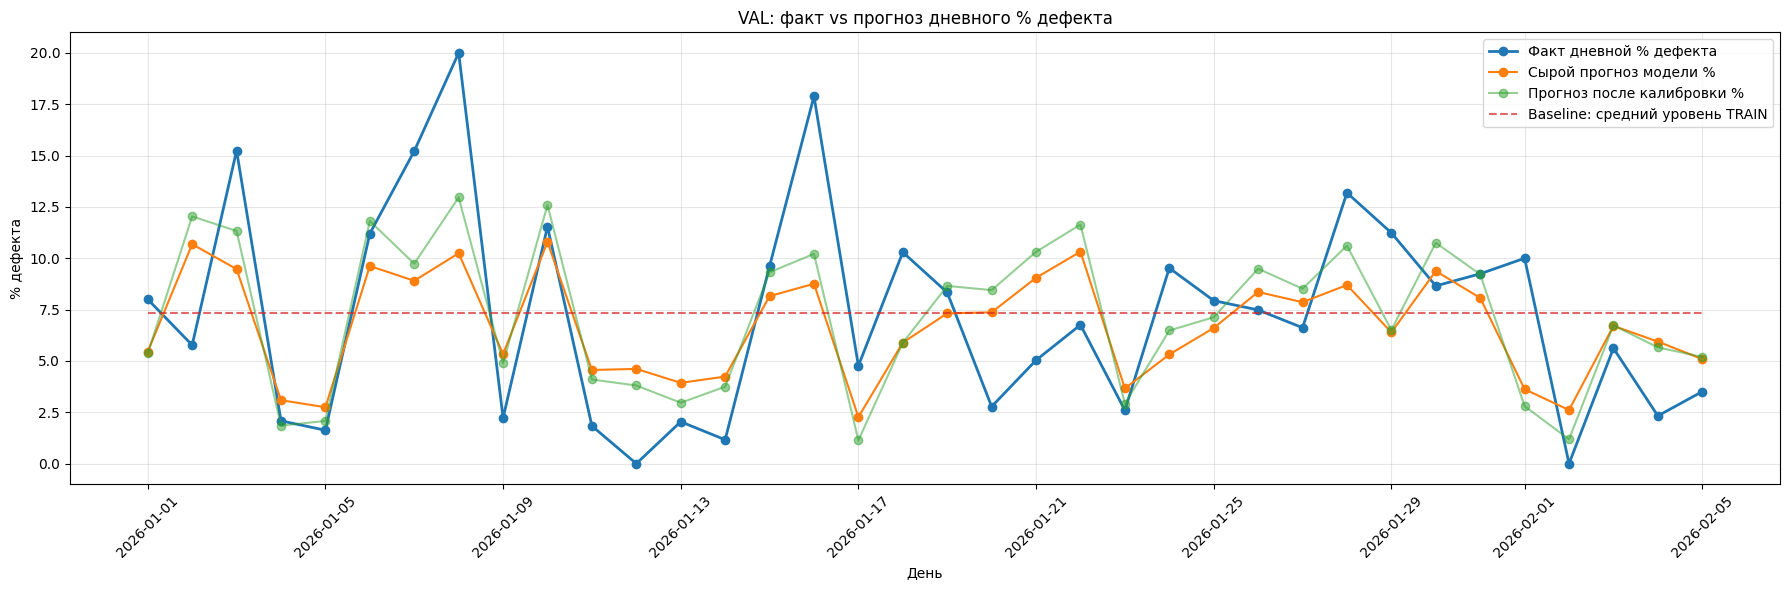

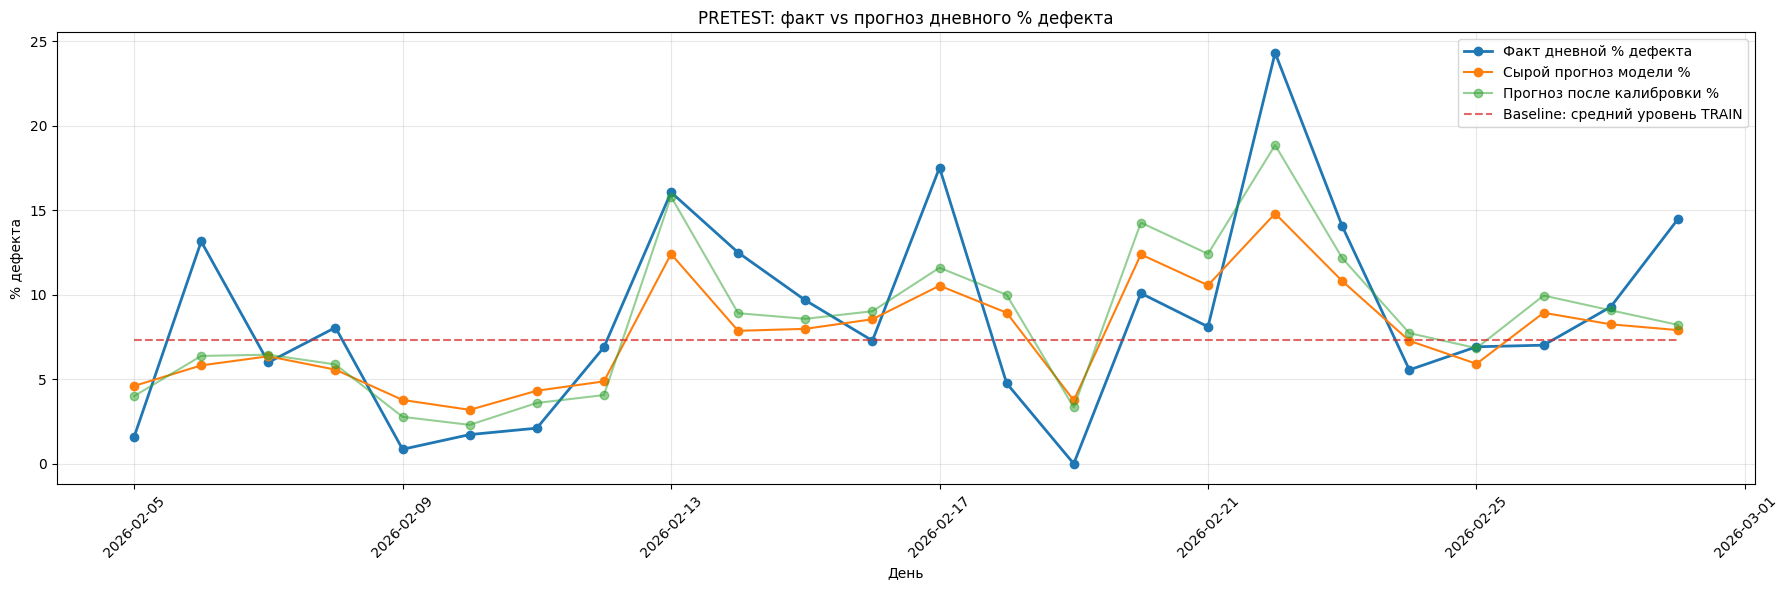

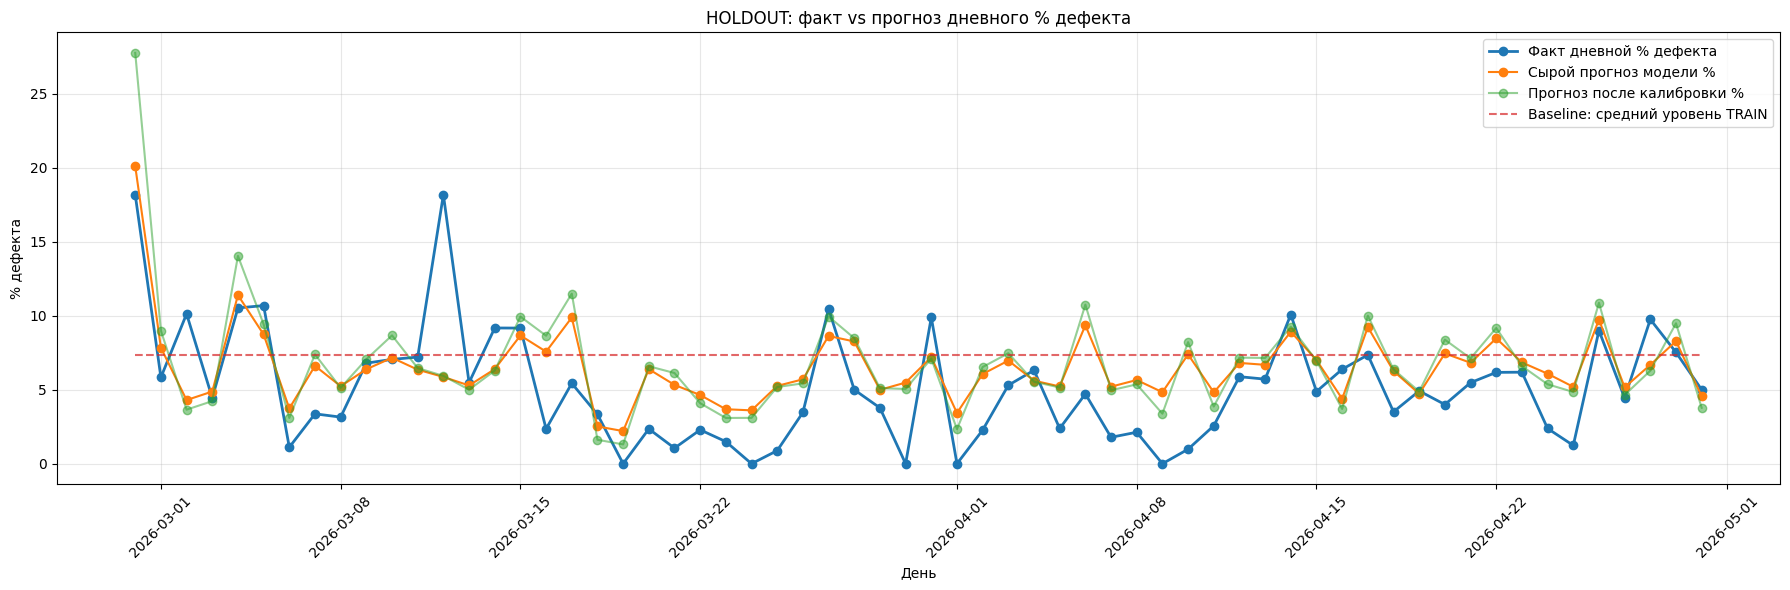

In [29]:
print_title("23. Графики дневного прогноза")

for split_name in ["VAL", "PRETEST", "HOLDOUT"]:
    d = daily[daily["split"] == split_name].copy().sort_values("day")

    if len(d) == 0:
        continue

    plt.figure(figsize=(18, 6))

    plt.plot(
        d["day"],
        d["fact_pct"] * 100,
        marker="o",
        linewidth=2,
        label="Факт дневной % дефекта",
    )

    plt.plot(
        d["day"],
        d["pred_raw_pct"] * 100,
        marker="o",
        label="Сырой прогноз модели %",
    )

    plt.plot(
        d["day"],
        d["pred_cal_pct"] * 100,
        marker="o",
        alpha=0.5,
        label="Прогноз после калибровки %",
    )

    plt.plot(
        d["day"],
        d["pred_base_train_pct"] * 100,
        linestyle="--",
        alpha=0.7,
        label="Baseline: средний уровень TRAIN",
    )

    plt.title(f"{split_name}: факт vs прогноз дневного % дефекта")
    plt.xlabel("День")
    plt.ylabel("% дефекта")
    plt.xticks(rotation=45)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


23.1. Бары: факт vs сырой прогноз + ошибка


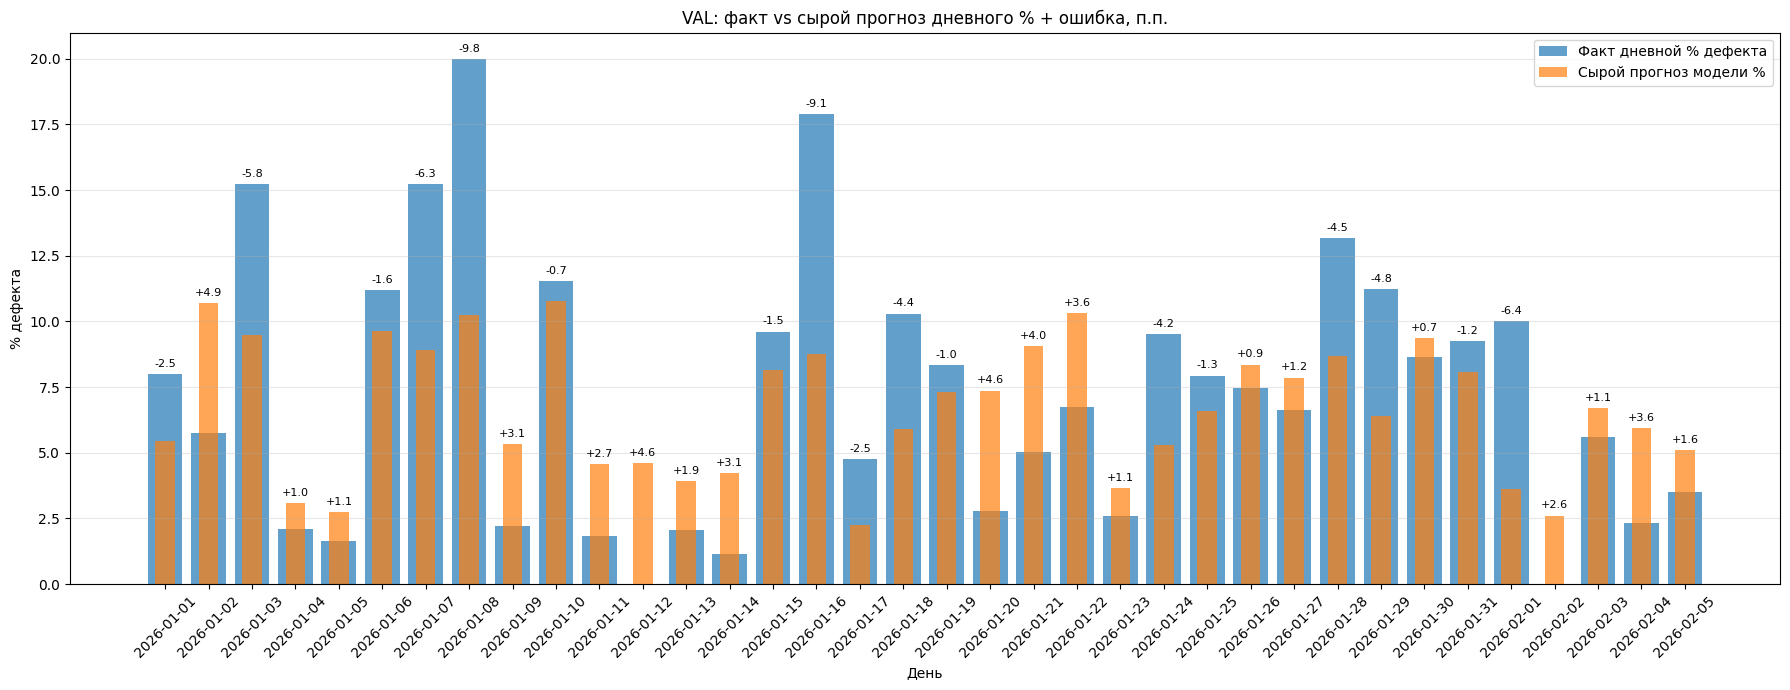

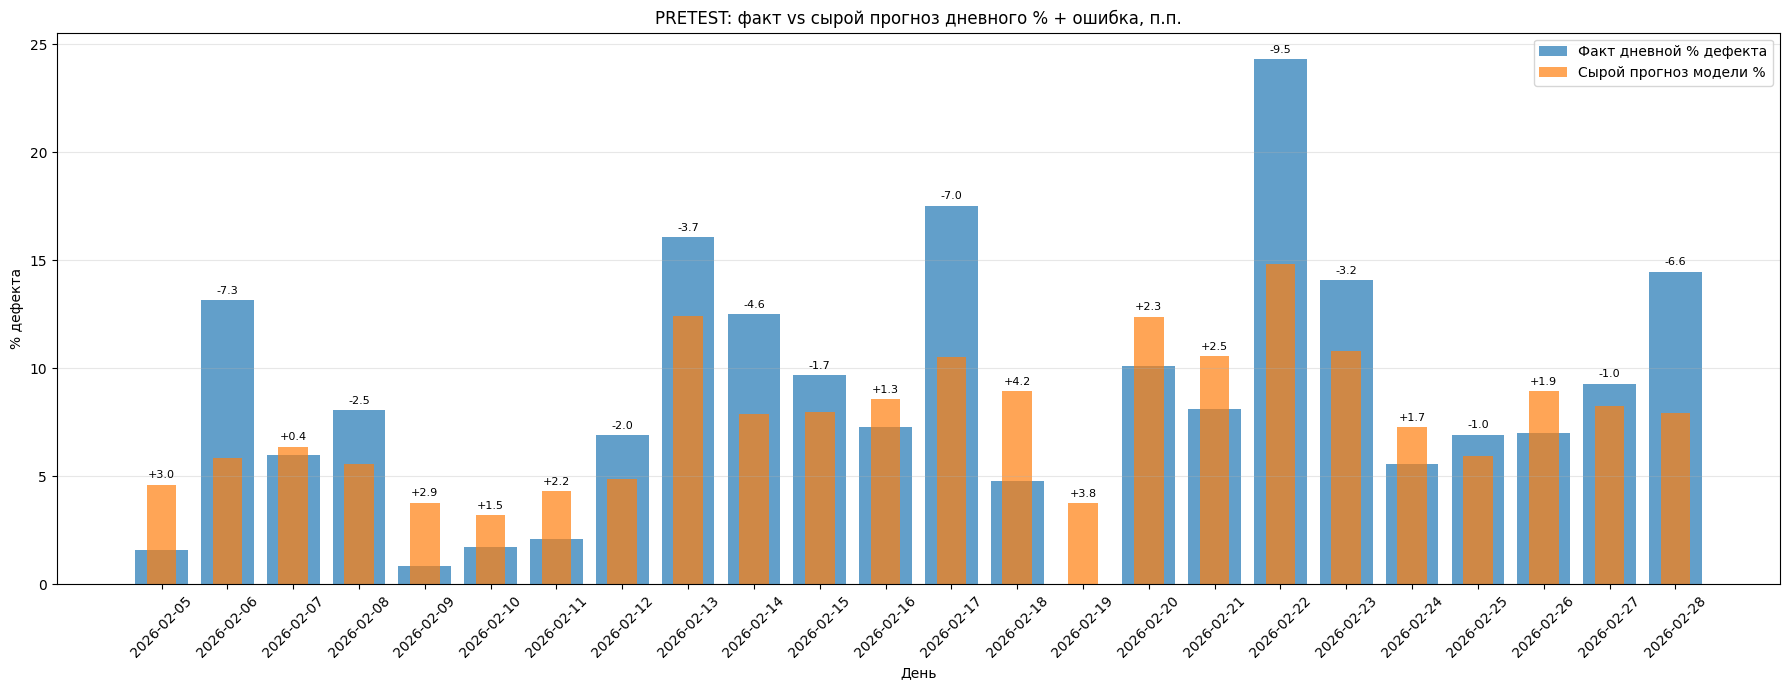

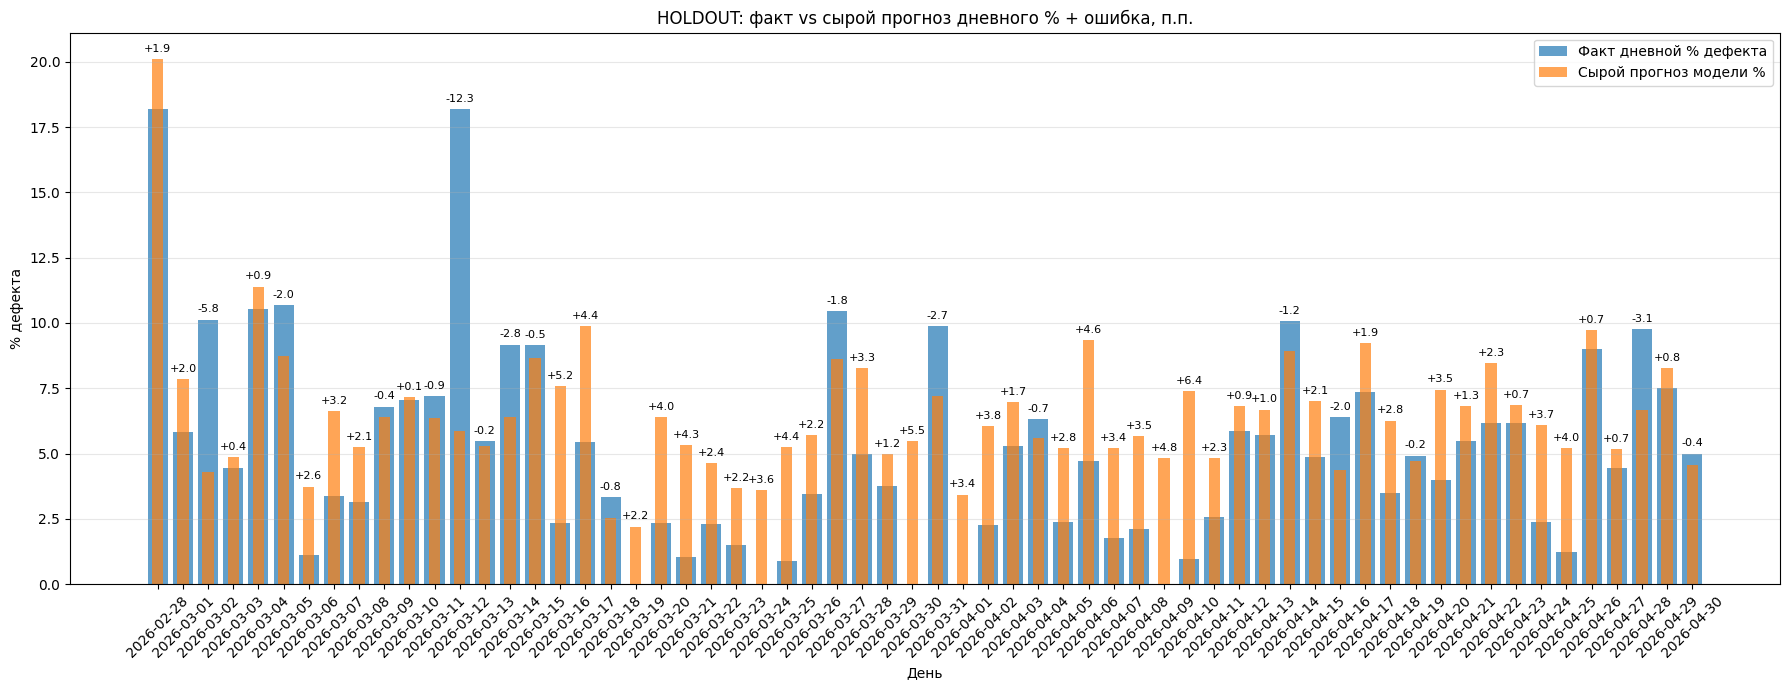

In [30]:
print_title("23.1. Бары: факт vs сырой прогноз + ошибка")

for split_name in ["VAL", "PRETEST", "HOLDOUT"]:
    d = daily[daily["split"] == split_name].copy().sort_values("day")

    if len(d) == 0:
        continue

    x = np.arange(len(d))

    fact = d["fact_pct"].values * 100
    pred = d["pred_raw_pct"].values * 100
    err_pp = d["error_raw_pp"].values

    labels = d["day"].dt.strftime("%Y-%m-%d")

    plt.figure(figsize=(18, 7))

    plt.bar(
        x,
        fact,
        width=0.80,
        alpha=0.7,
        label="Факт дневной % дефекта",
    )

    plt.bar(
        x,
        pred,
        width=0.45,
        alpha=0.7,
        label="Сырой прогноз модели %",
    )

    for i, (f, p, e) in enumerate(zip(fact, pred, err_pp)):
        y_text = max(f, p) + 0.2
        plt.text(
            i,
            y_text,
            f"{e:+.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    plt.title(f"{split_name}: факт vs сырой прогноз дневного % + ошибка, п.п.")
    plt.xlabel("День")
    plt.ylabel("% дефекта")
    plt.xticks(x, labels, rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [31]:
print_title("24. Финальная сводка")


# - какая модель лучшая на VALIDATION;
# - как она прошла PRETEST и HOLDOUT;
# - лучше ли она baseline;
# - насколько пригоден прогноз дневного процента дефекта.

# ML-метрики выбранной модели
best_ml_summary = (
    eval_results[eval_results["model_name"] == final_model_name]
    [main_cols]
    .sort_values("split")
    .copy()
)

print("Выбранная модель:", final_model_name)
display(best_ml_summary)

# Сравнение выбранной модели с лучшим baseline на HOLDOUT
holdout_compare = (
    eval_results[eval_results["split"] == "HOLDOUT"]
    .copy()
    .sort_values("quality_score", ascending=False)
    .reset_index(drop=True)
)

print("Сравнение моделей на HOLDOUT:")
display(holdout_compare[main_cols])

# Продуктовая часть: дневной прогноз на HOLDOUT
daily_holdout_metrics = (
    period_metrics[
        (period_metrics["period_type"] == "daily")
        & (period_metrics["split"] == "HOLDOUT")
    ][period_cols]
    .sort_values("WMAE_pp_n")
)

weekly_holdout_metrics = (
    period_metrics[
        (period_metrics["period_type"] == "weekly")
        & (period_metrics["split"] == "HOLDOUT")
    ][period_cols]
    .sort_values("WMAE_pp_n")
)

print("\nДневной прогноз процента дефекта на HOLDOUT:")
display(daily_holdout_metrics)

print("\nНедельный прогноз процента дефекта на HOLDOUT:")
display(weekly_holdout_metrics)


24. Финальная сводка
Выбранная модель: model_catboost_base


,model_name,model_type,baseline_role,split,thr,precision,recall,f1,pr_auc,roc_auc,...,recall_top_10,tp_top_10,n_top_10,topk_mode,tp,fp,fn,tn,row_quality_score,quality_score
20,model_catboost_base,complex_model,model,HOLDOUT,0.098148,0.152882,0.631034,0.246133,0.163123,0.820365,...,0.351724,102.0,558,ranked_by_model_score,183,1014,107,4277,0.298350,0.298350
19,model_catboost_base,complex_model,model,PRETEST,0.098148,0.211783,0.743017,0.329616,0.297595,0.838032,...,0.346369,62.0,212,ranked_by_model_score,133,495,46,1454,0.380865,0.380865
18,model_catboost_base,complex_model,model,VAL,0.098148,0.234940,0.770751,0.360111,0.307877,0.855258,...,0.422925,107.0,319,ranked_by_model_score,195,635,58,2302,0.415088,0.415088


Сравнение моделей на HOLDOUT:


,model_name,model_type,baseline_role,split,thr,precision,recall,f1,pr_auc,roc_auc,...,recall_top_10,tp_top_10,n_top_10,topk_mode,tp,fp,fn,tn,row_quality_score,quality_score
0,model_decision_tree,simple_model,model,HOLDOUT,0.178888,0.093047,0.941379,0.169355,0.149103,0.787361,...,0.379310,110.000000,558,ranked_by_model_score,273,2661,17,2630,0.341120,0.341120
1,model_catboost_base,complex_model,model,HOLDOUT,0.098148,0.152882,0.631034,0.246133,0.163123,0.820365,...,0.351724,102.000000,558,ranked_by_model_score,183,1014,107,4277,0.298350,0.298350
2,baseline_random,baseline,working_baseline,HOLDOUT,0.010000,0.051983,0.989655,0.098778,0.052818,0.503145,...,0.117241,34.000000,558,ranked_by_model_score,287,5234,3,57,0.257793,0.257793
3,baseline_all_positive,baseline,sanity_check,HOLDOUT,0.000000,0.051962,1.000000,0.098791,0.051962,0.500000,...,0.099982,28.994804,558,constant_score_expected_random,290,5291,0,0,0.255797,0.255797
4,model_logistic_regression,simple_model,model,HOLDOUT,0.045814,0.050462,0.941379,0.095789,0.066299,0.557667,...,0.137931,40.000000,558,ranked_by_model_score,273,5137,17,154,0.254124,0.254124
5,model_automl_flaml,automl,model,HOLDOUT,0.581369,0.166168,0.382759,0.231733,0.156692,0.805153,...,0.327586,95.000000,558,ranked_by_model_score,111,557,179,4734,0.242725,0.242725
6,baseline_train_rate,baseline,working_baseline,HOLDOUT,0.500000,0.000000,0.000000,0.000000,0.051962,0.500000,...,0.099982,28.994804,558,constant_score_expected_random,0,0,290,5291,0.030586,0.030586
7,baseline_all_negative,baseline,sanity_check,HOLDOUT,1.100000,0.000000,0.000000,0.000000,0.051962,0.500000,...,0.099982,28.994804,558,constant_score_expected_random,0,0,290,5291,0.030586,0.030586



Дневной прогноз процента дефекта на HOLDOUT:


,period_type,split,eval_role,prob_type,n_periods,n_units_sum,fact_cnt_sum,pred_cnt_sum,fact_pct_global,pred_pct_global,MAE_pp,RMSE_pp,BIAS_pp,WMAE_pp_n,WRMSE_pp_n,WBIAS_pp_n,MAE_cnt_per_period,BIAS_cnt_per_period,WAPE_cnt,corr_period
8,daily,HOLDOUT,final_check,raw_score,62,5581.0,290.0,368.238732,0.051962,0.065981,2.564975,3.242096,1.348158,2.485880,3.089407,1.401877,2.237693,1.261915,0.478403,0.643795
9,daily,HOLDOUT,final_check,calibrated_probability,62,5581.0,290.0,385.171074,0.051962,0.069015,2.856627,3.632638,1.620599,2.765209,3.413044,1.705269,2.489134,1.535017,0.532160,0.629560
10,daily,HOLDOUT,final_check,baseline_train_rate,62,5581.0,290.0,409.287326,0.051962,0.073336,3.692830,4.417881,2.162200,3.368350,3.981524,2.137383,3.032058,1.923989,0.648233,-0.004219
11,daily,HOLDOUT,final_check,baseline_val_rate,62,5581.0,290.0,442.631034,0.051962,0.079310,4.052149,4.739012,2.759650,3.719949,4.331679,2.734833,3.348554,2.461791,0.715898,0.008593



Недельный прогноз процента дефекта на HOLDOUT:


,period_type,split,eval_role,prob_type,n_periods,n_units_sum,fact_cnt_sum,pred_cnt_sum,fact_pct_global,pred_pct_global,MAE_pp,RMSE_pp,BIAS_pp,WMAE_pp_n,WRMSE_pp_n,WBIAS_pp_n,MAE_cnt_per_period,BIAS_cnt_per_period,WAPE_cnt,corr_period
20,weekly,HOLDOUT,final_check,raw_score,10,5581.0,290.0,368.238732,0.051962,0.065981,1.874051,2.199448,1.427956,1.888899,2.228853,1.401877,10.541945,7.823873,0.363515,0.448072
21,weekly,HOLDOUT,final_check,calibrated_probability,10,5581.0,290.0,385.171074,0.051962,0.069015,2.146263,2.531318,1.817769,2.035980,2.413661,1.705269,11.362806,9.517107,0.391821,0.425041
22,weekly,HOLDOUT,final_check,baseline_train_rate,10,5581.0,290.0,409.287326,0.051962,0.073336,2.200714,2.731061,1.989302,2.412776,2.877648,2.137383,13.465701,11.928733,0.464335,NaN
23,weekly,HOLDOUT,final_check,baseline_val_rate,10,5581.0,290.0,442.631034,0.051962,0.079310,2.678675,3.192594,2.586752,2.854574,3.345409,2.734833,15.931379,15.263103,0.549358,NaN


In [ ]:
print_title("25. Итоговый текстовый вывод")

# Итоговые метрики выбранной модели.
val_best_model = eval_results[
    (eval_results["split"] == "VAL")
    & (eval_results["model_name"] == final_model_name)
].iloc[0]

pretest_best_model = eval_results[
    (eval_results["split"] == "PRETEST")
    & (eval_results["model_name"] == final_model_name)
].iloc[0]

holdout_best_model = eval_results[
    (eval_results["split"] == "HOLDOUT")
    & (eval_results["model_name"] == final_model_name)
].iloc[0]

# Baseline отдельно: sanity и рабочие.
SANITY_BASELINES = ["baseline_all_negative"]

baseline_holdout_all = eval_results[
    (eval_results["split"] == "HOLDOUT")
    & (eval_results["model_type"] == "baseline")
].copy()

sanity_baseline_holdout = baseline_holdout_all[
    baseline_holdout_all["model_name"].isin(SANITY_BASELINES)
].copy()

working_baseline_holdout = baseline_holdout_all[
    ~baseline_holdout_all["model_name"].isin(SANITY_BASELINES)
].copy()

best_sanity_baseline_holdout = (
    sanity_baseline_holdout
    .sort_values("row_quality_score", ascending=False)
    .iloc[0]
    if len(sanity_baseline_holdout) > 0
    else None
)

best_working_baseline_holdout = (
    working_baseline_holdout
    .sort_values("row_quality_score", ascending=False)
    .iloc[0]
    if len(working_baseline_holdout) > 0
    else None
)

# Итоговые продуктовые метрики по дневному / недельному %
PRODUCT_PROB_TYPE = "calibrated_probability"


def get_period_result(period_type, split_name, prob_type=PRODUCT_PROB_TYPE):
    d = period_metrics[
        (period_metrics["period_type"] == period_type)
        & (period_metrics["split"] == split_name)
        & (period_metrics["prob_type"] == prob_type)
    ].copy()

    if len(d) == 0:
        d = period_metrics[
            (period_metrics["period_type"] == period_type)
            & (period_metrics["split"] == split_name)
            & (period_metrics["prob_type"] == "raw_score")
        ].copy()

    if len(d) == 0:
        return None

    return d.iloc[0]


def get_best_rate_baseline_period(period_type, split_name):
    d = period_metrics[
        (period_metrics["period_type"] == period_type)
        & (period_metrics["split"] == split_name)
        & (period_metrics["prob_type"].isin(["baseline_train_rate", "baseline_val_rate"]))
    ].copy()

    if len(d) == 0:
        return None

    return d.sort_values("WMAE_pp_n").iloc[0]


def print_model_split_metrics(split_label, row):
    print(f"\nПроверка модели на {split_label}:")
    print(f"- precision: {row['precision']:.4f}")
    print(f"- recall: {row['recall']:.4f}")
    print(f"- f1: {row['f1']:.4f}")
    print(f"- PR-AUC: {row['pr_auc']:.4f}")
    print(f"- ROC-AUC: {row['roc_auc']:.4f}")
    print(f"- flagged_share: {row['flagged_share']:.4f}")
    print(f"- TP: {int(row['tp'])}")
    print(f"- FP: {int(row['fp'])}")
    print(f"- FN: {int(row['fn'])}")
    print(f"- TN: {int(row['tn'])}")
    print(f"- Precision@Top-{int(TOP_K_SHARE * 100)}%: {row[top_p_col]:.4f}")
    print(f"- Recall@Top-{int(TOP_K_SHARE * 100)}%: {row[top_r_col]:.4f}")
    print(f"- TP@Top-{int(TOP_K_SHARE * 100)}%: {row[tp_top_col]:.1f}")
    print(f"- N@Top-{int(TOP_K_SHARE * 100)}%: {int(row[n_top_col])}")
    print(f"- topk_mode: {row['topk_mode']}")
    print(f"- row_quality_score: {row['row_quality_score']:.4f}")


daily_pretest = get_period_result("daily", "PRETEST")
daily_holdout = get_period_result("daily", "HOLDOUT")

weekly_pretest = get_period_result("weekly", "PRETEST")
weekly_holdout = get_period_result("weekly", "HOLDOUT")

daily_pretest_base = get_best_rate_baseline_period("daily", "PRETEST")
daily_holdout_base = get_best_rate_baseline_period("daily", "HOLDOUT")

weekly_pretest_base = get_best_rate_baseline_period("weekly", "PRETEST")
weekly_holdout_base = get_best_rate_baseline_period("weekly", "HOLDOUT")


print("ИТОГОВЫЙ ВЫВОД")
print("-" * 120)

print(f"1. В работе была построена baseline-схема для задачи прогнозирования дефекта: {TARGET_COL}.")
print("2. Random split не использовался, так как для производственных данных важна временная проверка.")
print("3. Модели сравнивались на одинаковых train / validation / pretest / holdout разбиениях.")
print("4. Порог классификации подбирался только на VALIDATION.")
print("5. HOLDOUT использовался только как финальная имитация будущих данных.")
print("6. quality_score / row_quality_score — это совокупная row-level ML-метрика, а не полная бизнес-метрика.")
print("7. Продуктовая полезность отдельно проверялась через дневной и недельный MAE/RMSE/BIAS/WMAE.")


print("\nЛучшая ML-модель по VALIDATION:")
print(f"- модель: {final_model_name}")
print(f"- тип модели: {val_best_model['model_type']}")
print(f"- выбранный threshold: {val_best_model['thr']:.6f}")

print_model_split_metrics("VALIDATION", val_best_model)
print_model_split_metrics("PRETEST", pretest_best_model)
print_model_split_metrics("HOLDOUT", holdout_best_model)


print("\nBaseline на HOLDOUT:")

if best_sanity_baseline_holdout is not None:
    print("\nЛучший sanity-check baseline:")
    print(f"- baseline: {best_sanity_baseline_holdout['model_name']}")
    print(f"- row_quality_score: {best_sanity_baseline_holdout['row_quality_score']:.4f}")
    print(f"- precision: {best_sanity_baseline_holdout['precision']:.4f}")
    print(f"- recall: {best_sanity_baseline_holdout['recall']:.4f}")
    print(f"- flagged_share: {best_sanity_baseline_holdout['flagged_share']:.4f}")
    print(
        "- комментарий: all-positive / all-negative нужны только как техническая проверка крайних случаев. "
        "Они не считаются применимыми производственными решениями."
    )

if best_working_baseline_holdout is not None:
    print("\nЛучший рабочий baseline:")
    print(f"- baseline: {best_working_baseline_holdout['model_name']}")
    print(f"- row_quality_score: {best_working_baseline_holdout['row_quality_score']:.4f}")
    print(f"- precision: {best_working_baseline_holdout['precision']:.4f}")
    print(f"- recall: {best_working_baseline_holdout['recall']:.4f}")
    print(f"- flagged_share: {best_working_baseline_holdout['flagged_share']:.4f}")
    print(f"- Precision@Top-{int(TOP_K_SHARE * 100)}%: {best_working_baseline_holdout[top_p_col]:.4f}")
    print(f"- Recall@Top-{int(TOP_K_SHARE * 100)}%: {best_working_baseline_holdout[top_r_col]:.4f}")

    if holdout_best_model["row_quality_score"] > best_working_baseline_holdout["row_quality_score"]:
        print("\nВывод: выбранная ML-модель превосходит рабочий baseline на HOLDOUT по row-level ML-метрике.")
    else:
        print("\nВывод: выбранная ML-модель НЕ превосходит рабочий baseline на HOLDOUT по row-level ML-метрике.")
else:
    print("\nРабочий baseline на HOLDOUT не найден. Есть только sanity-check baseline.")


print("\nПродуктовая часть: прогноз дневного и недельного % дефекта")
print("- вероятности модели были агрегированы в дневной и недельный процент дефекта;")
print("- для прогноза процента использовался mean(p), а для прогноза количества дефектов — sum(p);")
print("- дополнительно проверялась калиброванная вероятность, так как для дневного процента важен масштаб вероятностей;")
print("- threshold использовался отдельно только для формирования очереди контроля;")
print("- качество прогноза процента оценивалось через MAE/RMSE/BIAS в процентных пунктах.")
print("- отдельно модель сравнивалась с baseline_train_rate / baseline_val_rate.")


def print_period_block(title, model_row, base_row=None, corr_label="дням"):
    if model_row is None:
        return

    print(f"\n{title}:")
    print(f"- вариант вероятности модели: {model_row['prob_type']}")
    print(f"- периодов: {int(model_row['n_periods'])}")
    print(f"- факт по периоду: {model_row['fact_pct_global'] * 100:.2f}%")
    print(f"- прогноз модели по периоду: {model_row['pred_pct_global'] * 100:.2f}%")
    print(f"- MAE модели: {model_row['MAE_pp']:.2f} п.п.")
    print(f"- RMSE модели: {model_row['RMSE_pp']:.2f} п.п.")
    print(f"- BIAS модели: {model_row['BIAS_pp']:.2f} п.п.")
    print(f"- weighted MAE модели: {model_row['WMAE_pp_n']:.2f} п.п.")
    print(f"- weighted RMSE модели: {model_row['WRMSE_pp_n']:.2f} п.п.")
    print(f"- weighted BIAS модели: {model_row['WBIAS_pp_n']:.2f} п.п.")
    print(f"- корреляция по {corr_label}: {model_row['corr_period']:.3f}")

    if base_row is not None:
        delta = model_row["WMAE_pp_n"] - base_row["WMAE_pp_n"]
        better_text = "лучше" if delta < 0 else "не лучше"
        print(f"- лучший rate-baseline: {base_row['prob_type']}")
        print(f"- weighted MAE baseline: {base_row['WMAE_pp_n']:.2f} п.п.")
        print(f"- разница WMAE модель - baseline: {delta:+.2f} п.п.")
        print(f"- вывод по WMAE: модель {better_text} простого baseline среднего процента.")


print_period_block(
    "Дневной прогноз % дефекта на PRETEST",
    daily_pretest,
    daily_pretest_base,
    corr_label="дням",
)

print_period_block(
    "Дневной прогноз % дефекта на HOLDOUT",
    daily_holdout,
    daily_holdout_base,
    corr_label="дням",
)

print_period_block(
    "Недельный прогноз % дефекта на PRETEST",
    weekly_pretest,
    weekly_pretest_base,
    corr_label="неделям",
)

print_period_block(
    "Недельный прогноз % дефекта на HOLDOUT",
    weekly_holdout,
    weekly_holdout_base,
    corr_label="неделям",
)


print("\nОбщий вывод:")
print(
    "На этом этапе получено простое, честное и проверяемое baseline-решение. "
    "Модель обучалась и сравнивалась с соблюдением временной структуры данных: "
    "порог подбирался на VALIDATION, PRETEST использовался как дополнительная проверка, "
    "а HOLDOUT — как финальная имитация будущих данных. "
    "Для row-level задачи модель оценивается через precision, recall, F1, PR-AUC, "
    f"Precision@Top-{int(TOP_K_SHARE * 100)}% и Recall@Top-{int(TOP_K_SHARE * 100)}%. "
    "Top-K метрики особенно важны, потому что они показывают качество ограниченной очереди контроля. "
    "Наивный baseline all-negative использовался как простая точка отсчёта, "
    "а рабочее сравнение дополнительно выполнялось с baseline средней частоты дефекта на TRAIN. "
    "Продуктовая часть проверялась отдельно через ошибку прогноза дневного и недельного процента дефекта. "
    "Если row-level ML-метрики улучшаются, но WMAE дневного процента не всегда лучше простого среднего baseline, "
    "это означает, что модель уже может быть полезна для risk queue, "
    "но для точного прогноза дневного процента может потребоваться отдельная калибровка или отдельная агрегирующая модель."
)


25. Итоговый текстовый вывод
ИТОГОВЫЙ ВЫВОД
------------------------------------------------------------------------------------------------------------------------
1. В работе была построена baseline-схема для задачи прогнозирования дефекта: Карантины ПК | Неплоскостность | Стан 2000 | После стана.
2. Random split не использовался, так как для производственных данных важна временная проверка.
3. Модели сравнивались на одинаковых train / validation / pretest / holdout разбиениях.
4. Порог классификации подбирался только на VALIDATION.
5. HOLDOUT использовался только как финальная имитация будущих данных.
6. quality_score / row_quality_score — это совокупная row-level ML-метрика, а не полная бизнес-метрика.
7. Продуктовая полезность отдельно проверялась через дневной и недельный MAE/RMSE/BIAS/WMAE.

Лучшая ML-модель по VALIDATION:
- модель: model_catboost_base
- тип модели: complex_model
- выбранный threshold: 0.098148

Проверка модели на VALIDATION:
- precision: 0.2349
- recall: 0.770

In [33]:
print_title("26. Мини-диагностика: почему просели метрики на HOLDOUT")

# 1. Сравнение метрик модели
m_pre = eval_results[
    (eval_results["split"] == "PRETEST")
    & (eval_results["model_name"] == final_model_name)
].iloc[0]

m_hold = eval_results[
    (eval_results["split"] == "HOLDOUT")
    & (eval_results["model_name"] == final_model_name)
].iloc[0]

# 2. Сравнение продуктовых метрик дневного прогноза
d_pre = period_metrics[
    (period_metrics["period_type"] == "daily")
    & (period_metrics["split"] == "PRETEST")
    & (period_metrics["prob_type"] == "calibrated_probability")
].iloc[0]

d_hold = period_metrics[
    (period_metrics["period_type"] == "daily")
    & (period_metrics["split"] == "HOLDOUT")
    & (period_metrics["prob_type"] == "calibrated_probability")
].iloc[0]

# 3. Сравнение распределения таргета и вероятностей
p_pre = predictions[final_model_name]["p_pretest"]
p_hold = predictions[final_model_name]["p_holdout"]

summary = pd.DataFrame([
    {
        "block": "ML метрики",
        "metric": "precision",
        "PRETEST": m_pre["precision"],
        "HOLDOUT": m_hold["precision"],
        "diff_holdout_minus_pretest": m_hold["precision"] - m_pre["precision"],
    },
    {
        "block": "ML метрики",
        "metric": "recall",
        "PRETEST": m_pre["recall"],
        "HOLDOUT": m_hold["recall"],
        "diff_holdout_minus_pretest": m_hold["recall"] - m_pre["recall"],
    },
    {
        "block": "ML метрики",
        "metric": "PR-AUC",
        "PRETEST": m_pre["pr_auc"],
        "HOLDOUT": m_hold["pr_auc"],
        "diff_holdout_minus_pretest": m_hold["pr_auc"] - m_pre["pr_auc"],
    },
    {
        "block": "Таргет",
        "metric": "fact_rate",
        "PRETEST": float(y_pretest.mean()),
        "HOLDOUT": float(y_holdout.mean()),
        "diff_holdout_minus_pretest": float(y_holdout.mean() - y_pretest.mean()),
    },
    {
        "block": "Скор модели",
        "metric": "mean_p_raw",
        "PRETEST": float(np.mean(p_pre)),
        "HOLDOUT": float(np.mean(p_hold)),
        "diff_holdout_minus_pretest": float(np.mean(p_hold) - np.mean(p_pre)),
    },
    {
        "block": "Дневной прогноз",
        "metric": "daily_WMAE_pp",
        "PRETEST": d_pre["WMAE_pp_n"],
        "HOLDOUT": d_hold["WMAE_pp_n"],
        "diff_holdout_minus_pretest": d_hold["WMAE_pp_n"] - d_pre["WMAE_pp_n"],
    },
    {
        "block": "Дневной прогноз",
        "metric": "daily_corr",
        "PRETEST": d_pre["corr_period"],
        "HOLDOUT": d_hold["corr_period"],
        "diff_holdout_minus_pretest": d_hold["corr_period"] - d_pre["corr_period"],
    },
])

display(summary)


# 4. Очень простой feature drift: сравниваем средние по числовым признакам
num_cols_drift = [
    c for c in X_pretest.columns
    if c in X_holdout.columns
    and pd.api.types.is_numeric_dtype(X_pretest[c])
]

drift_rows = []

for c in num_cols_drift:
    pre = pd.to_numeric(X_pretest[c], errors="coerce")
    hold = pd.to_numeric(X_holdout[c], errors="coerce")

    pre_mean = pre.mean()
    hold_mean = hold.mean()
    pre_std = pre.std()

    if pd.isna(pre_mean) or pd.isna(hold_mean) or pd.isna(pre_std) or pre_std == 0:
        continue

    drift_z = (hold_mean - pre_mean) / pre_std

    drift_rows.append({
        "feature": c,
        "pretest_mean": pre_mean,
        "holdout_mean": hold_mean,
        "diff": hold_mean - pre_mean,
        "drift_z": drift_z,
        "abs_drift_z": abs(drift_z),
    })

drift_df = (
    pd.DataFrame(drift_rows)
    .sort_values("abs_drift_z", ascending=False)
    .reset_index(drop=True)
)

print("\nТОП признаков с наибольшим сдвигом среднего PRETEST -> HOLDOUT:")
display(drift_df.head(15))


# 5. Короткий вывод
print("\nКРАТКИЙ ВЫВОД:")

target_diff_pp = (float(y_holdout.mean()) - float(y_pretest.mean())) * 100
pr_auc_diff = float(m_hold["pr_auc"] - m_pre["pr_auc"])
recall_diff = float(m_hold["recall"] - m_pre["recall"])
precision_diff = float(m_hold["precision"] - m_pre["precision"])

print(f"- Доля дефекта изменилась с {float(y_pretest.mean())*100:.2f}% до {float(y_holdout.mean())*100:.2f}% ({target_diff_pp:+.2f} п.п.).")
print(f"- PR-AUC изменился на {pr_auc_diff:+.4f}.")
print(f"- Precision изменился на {precision_diff:+.4f}.")
print(f"- Recall изменился на {recall_diff:+.4f}.")
print(f"- Средний score модели изменился с {float(np.mean(p_pre))*100:.2f}% до {float(np.mean(p_hold))*100:.2f}%.")

if len(drift_df) > 0:
    print(f"- Есть признаки со сдвигом распределения. Максимальный простой drift_z: {drift_df.iloc[0]['abs_drift_z']:.2f}.")
    print(f"- Самый заметный сдвиг: {drift_df.iloc[0]['feature']}.")

if abs(target_diff_pp) >= 1.0:
    print("- Вероятная причина просадки: изменился уровень таргета / структура дефектов между PRETEST и HOLDOUT.")

if len(drift_df) > 0 and drift_df.iloc[0]["abs_drift_z"] >= 0.5:
    print("- Дополнительная причина: есть time-drift по признакам, то есть HOLDOUT отличается от PRETEST по распределению входных данных.")

print("- Это не доказывает единственную причину, но быстро показывает, где искать просадку качества.")


26. Мини-диагностика: почему просели метрики на HOLDOUT


,block,metric,PRETEST,HOLDOUT,diff_holdout_minus_pretest
0,ML метрики,precision,0.211783,0.152882,-0.058901
1,ML метрики,recall,0.743017,0.631034,-0.111982
2,ML метрики,PR-AUC,0.297595,0.163123,-0.134472
3,Таргет,fact_rate,0.084117,0.051962,-0.032155
4,Скор модели,mean_p_raw,0.075665,0.065981,-0.009684
5,Дневной прогноз,daily_WMAE_pp,2.542697,2.765209,0.222512
6,Дневной прогноз,daily_corr,0.809139,0.629560,-0.179579



ТОП признаков с наибольшим сдвигом среднего PRETEST -> HOLDOUT:


,feature,pretest_mean,holdout_mean,diff,drift_z,abs_drift_z
0,Границы КС | Расход воды на ЗВО секция 5 больш...,0.360486,-7.692691,-8.053176e+00,-131.830581,131.830581
1,Границы КС | Расход воды на ЗВО секция 4 больш...,0.423582,-1.614344,-2.037926e+00,-30.563767,30.563767
2,Границы КС | Расход воды на ЗВО секция 5 больш...,2.523401,10.363086,7.839685e+00,18.333675,18.333675
3,Границы КС | Расход воды на ЗВО секция 4 больш...,2.965076,4.752574,1.787498e+00,3.829711,3.829711
4,Плановая неделя отгрузки (СЗ истор),9.576742,16.006994,6.430252e+00,2.918702,2.918702
5,Плановая неделя отгрузки (СЗ),9.576742,16.006994,6.430252e+00,2.918702,2.918702
6,"Наработка раб.валков гор. кл. 2, т",449462.989869,107264.752454,-3.421982e+05,-2.094776,2.094776
7,"Наработка валков верт. кл. 3, т",257111.411996,114248.210553,-1.428632e+05,-1.143316,1.143316
8,"Наработка валков верт. кл. 4, т",254384.008560,116338.502506,-1.380455e+05,-1.128334,1.128334
9,"Наработка валков верт. кл. 5, т",257268.910782,118505.670409,-1.387632e+05,-1.109085,1.109085



КРАТКИЙ ВЫВОД:
- Доля дефекта изменилась с 8.41% до 5.20% (-3.22 п.п.).
- PR-AUC изменился на -0.1345.
- Precision изменился на -0.0589.
- Recall изменился на -0.1120.
- Средний score модели изменился с 7.57% до 6.60%.
- Есть признаки со сдвигом распределения. Максимальный простой drift_z: 131.83.
- Самый заметный сдвиг: Границы КС | Расход воды на ЗВО секция 5 большой радиус_Зеленая, мин.
- Вероятная причина просадки: изменился уровень таргета / структура дефектов между PRETEST и HOLDOUT.
- Дополнительная причина: есть time-drift по признакам, то есть HOLDOUT отличается от PRETEST по распределению входных данных.
- Это не доказывает единственную причину, но быстро показывает, где искать просадку качества.


### Проверка идеи multivariate time series classification

In [34]:
print_title("26.1. Выбор топ-65 признаков для time-series эксперимента")

# Идея дополнительного эксперимента:
# это не полноценная sequence-модель, а упрощённая имитация multivariate time series classification.
#
# Вместо того чтобы подавать в модель отдельные временные окна как последовательности,
# мы добавляем causal lag/window-признаки к обычной row-level классификации.
#
# Такой эксперимент безопасен для baseline-решения:
# - берём топ-65 сильных признаков по CatBoost importance;
# - по числовым признакам строим временной контекст;
# - rolling/lag считаются только через shift(1), то есть без будущей информации.


TOP_N_TS = 65

# Importance берём из уже обученного CatBoost.
# Это честно, потому что CatBoost обучался только на TRAIN.
catboost_importance = pd.DataFrame({
    "feature": list(X_train.columns),
    "importance": catboost_model.get_feature_importance(),
})

catboost_importance = (
    catboost_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top65_features = catboost_importance.head(TOP_N_TS)["feature"].tolist()

# Для rolling/lag-признаков нужны числовые признаки.
# Поэтому отдельно берём топ-65 числовых признаков по importance.
top65_numeric_features = (
    catboost_importance[
        catboost_importance["feature"].isin(num_cols)
    ]
    .head(TOP_N_TS)["feature"]
    .tolist()
)

print("Топ признаков всего:", len(top65_features))
print("Топ числовых признаков для lag/window:", len(top65_numeric_features))

print("\nТоп-20 признаков CatBoost:")
display(catboost_importance.head(20))

print("\nТоп-20 числовых признаков для временного контекста:")
display(
    catboost_importance[
        catboost_importance["feature"].isin(top65_numeric_features)
    ].head(20)
)


26.1. Выбор топ-65 признаков для time-series эксперимента
Топ признаков всего: 65
Топ числовых признаков для lag/window: 65

Топ-20 признаков CatBoost:


,feature,importance
0,"Толщина металла за 12-й клетью, сред",9.052654
1,Толщина (СЗ истор),6.372286
2,"Толщина металла за 12-й клетью (PM), сред",5.295722
3,Заданный план охлаждения (PM),5.047184
4,"Скорость смотки, сред",4.972557
5,Толщина (СЗ),4.848488
6,Толщина за 12-й клетью фактическое задание,4.198459
7,Стандарт поставки (СЗ),3.726790
8,"Толщина за последней клетью, сред",3.438694
9,"Тсм_Зеленая, макс",3.004384



Топ-20 числовых признаков для временного контекста:


,feature,importance
0,"Толщина металла за 12-й клетью, сред",9.052654
1,Толщина (СЗ истор),6.372286
2,"Толщина металла за 12-й клетью (PM), сред",5.295722
4,"Скорость смотки, сред",4.972557
5,Толщина (СЗ),4.848488
6,Толщина за 12-й клетью фактическое задание,4.198459
8,"Толщина за последней клетью, сред",3.438694
9,"Тсм_Зеленая, макс",3.004384
10,Границы ЛПЦ-2 | Скорость хвоста по 12-й клети_...,1.544637
11,"Ткп_Зеленая, макс",1.514124


In [35]:
print_title("26.2. Создание lag/window-признаков")

# Собираем все сплиты обратно в правильном временном порядке.
# Важно: данные уже были отсортированы по времени ранее.
X_seq = pd.concat(
    [X_train, X_val, X_pretest, X_holdout],
    axis=0,
    ignore_index=True,
)

y_seq = pd.concat(
    [y_train, y_val, y_pretest, y_holdout],
    axis=0,
    ignore_index=True,
)

n_train = len(X_train)
n_val = len(X_val)
n_pretest = len(X_pretest)
n_holdout = len(X_holdout)

assert len(X_seq) == len(y_seq)
assert len(X_seq) == n_train + n_val + n_pretest + n_holdout


def make_lag_window_features(X_seq, current_features, window_numeric_features):
    """
    - rolling-статистики считаются только по прошлым строкам через shift(1);
    - текущий таргет и будущие строки не используются;
    - для каждой строки доступны только текущие признаки и история до неё.
    """
    X_out = X_seq[current_features].copy().reset_index(drop=True)

    lag_dict = {}

    for c in window_numeric_features:
        s = pd.to_numeric(X_seq[c], errors="coerce").astype(float)

        prev = s.shift(1)

        roll5_mean_prev = prev.rolling(window=5, min_periods=2).mean()
        roll20_mean_prev = prev.rolling(window=20, min_periods=5).mean()
        roll20_std_prev = prev.rolling(window=20, min_periods=5).std()

        lag_dict[f"{c}__prev1"] = prev
        lag_dict[f"{c}__roll5_mean_prev"] = roll5_mean_prev
        lag_dict[f"{c}__roll20_mean_prev"] = roll20_mean_prev
        lag_dict[f"{c}__roll20_std_prev"] = roll20_std_prev

        # Текущее значение относительно прошлого поведения процесса
        lag_dict[f"{c}__delta_vs_prev1"] = s - prev
        lag_dict[f"{c}__delta_vs_roll20_mean_prev"] = s - roll20_mean_prev
        lag_dict[f"{c}__z_vs_roll20_prev"] = (
            (s - roll20_mean_prev)
            / roll20_std_prev.replace(0, np.nan)
        )

    X_lags = pd.DataFrame(lag_dict)

    X_new = pd.concat(
        [X_out, X_lags],
        axis=1,
    )

    return X_new


X_ts_all = make_lag_window_features(
    X_seq=X_seq,
    current_features=top65_features,
    window_numeric_features=top65_numeric_features,
)

X_ts_train = X_ts_all.iloc[:n_train].copy()
X_ts_val = X_ts_all.iloc[n_train:n_train + n_val].copy()
X_ts_pretest = X_ts_all.iloc[n_train + n_val:n_train + n_val + n_pretest].copy()
X_ts_holdout = X_ts_all.iloc[n_train + n_val + n_pretest:].copy()

y_ts_train = y_train.copy()
y_ts_val = y_val.copy()
y_ts_pretest = y_pretest.copy()
y_ts_holdout = y_holdout.copy()

# Категориальные признаки оставляем как строки для CatBoost.
cat_cols_ts = list(X_ts_train.select_dtypes(include=["object", "category"]).columns)
num_cols_ts = [c for c in X_ts_train.columns if c not in cat_cols_ts]

for c in cat_cols_ts:
    X_ts_train[c] = X_ts_train[c].astype("object").where(X_ts_train[c].notna(), NA_TOKEN).astype(str)
    X_ts_val[c] = X_ts_val[c].astype("object").where(X_ts_val[c].notna(), NA_TOKEN).astype(str)
    X_ts_pretest[c] = X_ts_pretest[c].astype("object").where(X_ts_pretest[c].notna(), NA_TOKEN).astype(str)
    X_ts_holdout[c] = X_ts_holdout[c].astype("object").where(X_ts_holdout[c].notna(), NA_TOKEN).astype(str)

assert list(X_ts_train.columns) == list(X_ts_val.columns) == list(X_ts_pretest.columns) == list(X_ts_holdout.columns)

print("X_ts_train:", X_ts_train.shape)
print("X_ts_val:", X_ts_val.shape)
print("X_ts_pretest:", X_ts_pretest.shape)
print("X_ts_holdout:", X_ts_holdout.shape)
print("Категориальных признаков:", len(cat_cols_ts))
print("Числовых признаков:", len(num_cols_ts))

display(X_ts_train.head())


26.2. Создание lag/window-признаков
X_ts_train: (15954, 520)
X_ts_val: (3190, 520)
X_ts_pretest: (2128, 520)
X_ts_holdout: (5581, 520)
Категориальных признаков: 10
Числовых признаков: 510


,"Толщина металла за 12-й клетью, сред",Толщина (СЗ истор),"Толщина металла за 12-й клетью (PM), сред",Заданный план охлаждения (PM),"Скорость смотки, сред",Толщина (СЗ),Толщина за 12-й клетью фактическое задание,Стандарт поставки (СЗ),"Толщина за последней клетью, сред","Тсм_Зеленая, макс",...,"Границы КС | Выдержка в сталь-ковше_Зеленая, макс__delta_vs_prev1","Границы КС | Выдержка в сталь-ковше_Зеленая, макс__delta_vs_roll20_mean_prev","Границы КС | Выдержка в сталь-ковше_Зеленая, макс__z_vs_roll20_prev",Химия | B__prev1,Химия | B__roll5_mean_prev,Химия | B__roll20_mean_prev,Химия | B__roll20_std_prev,Химия | B__delta_vs_prev1,Химия | B__delta_vs_roll20_mean_prev,Химия | B__z_vs_roll20_prev
0,7.81,8.0,7.810311,1.1.1.30.30.70.70.0.0.0.0.0.0.0.0.0.0.0.0,5.70,8.0,7.877,ГОСТ 27772-2021,7.812760,550.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,9.84,10.0,9.842260,1.1.1.30.30.70.70.2.0.0.0.0.0.0.0.0.0.0.0,3.80,10.0,9.855,СТО 00186217-308-2021,9.835809,590.0,...,NaN,NaN,NaN,0.0005,NaN,NaN,NaN,-0.0002,NaN,NaN
2,9.56,9.5,9.554921,1.1.1.30.30.70.70.2.0.0.0.0.0.0.0.0.0.0.0,4.54,9.5,9.635,СТО 00186217-681-2023,9.555242,660.0,...,NaN,NaN,NaN,0.0003,0.000400,NaN,NaN,0.0000,NaN,NaN
3,8.07,8.0,8.064728,1.1.1.30.30.70.70.2.0.15.20.15.20.0.0.0.0.0.0,4.20,8.0,8.122,СТО 00186217-681-2023,8.065206,580.0,...,NaN,NaN,NaN,0.0003,0.000367,NaN,NaN,0.0002,NaN,NaN
4,8.06,8.0,8.059280,1.1.1.30.30.70.70.2.0.15.20.15.20.0.0.0.0.0.0,4.73,8.0,8.122,СТО 00186217-681-2023,8.061711,580.0,...,NaN,NaN,NaN,0.0005,0.000400,NaN,NaN,0.0000,NaN,NaN


In [36]:
print_title("26.3. Обучение CatBoost на lag/window-признаках")

mts_model_name = "model_mts_lag_catboost_top65"

cat_idx_ts = [X_ts_train.columns.get_loc(c) for c in cat_cols_ts]

catboost_ts_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=10,
    random_seed=RANDOM_STATE,
    verbose=200,
    od_type="Iter",
    od_wait=100,
)

# Early stopping только внутри TRAIN
ts_i = int(len(X_ts_train) * 0.85)

X_ts_fit = X_ts_train.iloc[:ts_i].copy()
y_ts_fit = y_ts_train.iloc[:ts_i].copy()

X_ts_es = X_ts_train.iloc[ts_i:].copy()
y_ts_es = y_ts_train.iloc[ts_i:].copy()

print("TS CatBoost train part:", X_ts_fit.shape)
print("TS CatBoost early stopping part:", X_ts_es.shape)

catboost_ts_model.fit(
    X_ts_fit,
    y_ts_fit,
    cat_features=cat_idx_ts,
    eval_set=(X_ts_es, y_ts_es),
    use_best_model=True,
)

p_val_ts = catboost_ts_model.predict_proba(X_ts_val)[:, 1]
p_pretest_ts = catboost_ts_model.predict_proba(X_ts_pretest)[:, 1]
p_holdout_ts = catboost_ts_model.predict_proba(X_ts_holdout)[:, 1]

thr_ts, threshold_table_ts = pick_best_threshold_on_val(y_ts_val, p_val_ts)

print("\nTS CatBoost обучен.")
print("Модель:", mts_model_name)
print("Порог по VALIDATION:", thr_ts)
print("VAL PR-AUC:", round(safe_average_precision(y_ts_val, p_val_ts), 5))
print("VAL ROC-AUC:", round(safe_roc_auc(y_ts_val, p_val_ts), 5))
print("Средний score VAL:", round(float(np.mean(p_val_ts)), 5))
print("Факт VAL:", round(float(np.mean(y_ts_val)), 5))


26.3. Обучение CatBoost на lag/window-признаках
TS CatBoost train part: (13560, 520)
TS CatBoost early stopping part: (2394, 520)
0:	test: 0.5953982	best: 0.5953982 (0)	total: 97.1ms	remaining: 1m 37s
200:	test: 0.8538238	best: 0.8552165 (177)	total: 18.5s	remaining: 1m 13s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8552164706
bestIteration = 177

Shrink model to first 178 iterations.

TS CatBoost обучен.
Модель: model_mts_lag_catboost_top65
Порог по VALIDATION: 0.12936378696273318
VAL PR-AUC: 0.31725
VAL ROC-AUC: 0.85887
Средний score VAL: 0.07136
Факт VAL: 0.07931


In [37]:
print_title("26.4. Сравнение обычного CatBoost и time-series CatBoost")

mts_eval_rows = []

for split_name, y_true, p_model in [
    ("VAL", y_ts_val, p_val_ts),
    ("PRETEST", y_ts_pretest, p_pretest_ts),
    ("HOLDOUT", y_ts_holdout, p_holdout_ts),
]:
    m = evaluate_at_threshold(
        y_true=y_true,
        p=p_model,
        thr=thr_ts,
        top_k_share=TOP_K_SHARE,
    )

    m["model_name"] = mts_model_name
    m["model_type"] = "extra_experiment"
    m["baseline_role"] = "extra_experiment"
    m["split"] = split_name

    mts_eval_rows.append(m)

mts_eval_results = pd.DataFrame(mts_eval_rows)

for c in main_cols:
    if c not in mts_eval_results.columns:
        mts_eval_results[c] = np.nan

base_catboost_compare = (
    eval_results[
        (eval_results["model_name"] == "model_catboost_base")
        & (eval_results["split"].isin(["VAL", "PRETEST", "HOLDOUT"]))
    ][main_cols]
    .copy()
)

base_catboost_compare["experiment"] = "base_catboost"

mts_compare = mts_eval_results[main_cols].copy()
mts_compare["experiment"] = "mts_lag_catboost_top65"

compare_ts = pd.concat(
    [base_catboost_compare, mts_compare],
    axis=0,
    ignore_index=True,
)

compare_cols = [
    "experiment",
    "model_name",
    "model_type",
    "baseline_role",
    "split",
    "thr",
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "roc_auc",
    "flagged_share",
    top_p_col,
    top_r_col,
    tp_top_col,
    n_top_col,
    "topk_mode",
    "row_quality_score",
    "quality_score",
]

display(
    compare_ts[compare_cols]
    .sort_values(["split", "row_quality_score"], ascending=[True, False])
    .reset_index(drop=True)
)

print("\nКраткое сравнение на HOLDOUT:")

base_h = compare_ts[
    (compare_ts["experiment"] == "base_catboost")
    & (compare_ts["split"] == "HOLDOUT")
].iloc[0]

ts_h = compare_ts[
    (compare_ts["experiment"] == "mts_lag_catboost_top65")
    & (compare_ts["split"] == "HOLDOUT")
].iloc[0]

print(f"Base CatBoost HOLDOUT PR-AUC: {base_h['pr_auc']:.4f}")
print(f"TS CatBoost HOLDOUT PR-AUC:   {ts_h['pr_auc']:.4f}")
print(f"Разница PR-AUC:               {ts_h['pr_auc'] - base_h['pr_auc']:+.4f}")

print(f"\nBase CatBoost HOLDOUT row_quality_score: {base_h['row_quality_score']:.4f}")
print(f"TS CatBoost HOLDOUT row_quality_score:   {ts_h['row_quality_score']:.4f}")
print(f"Разница row_quality_score:               {ts_h['row_quality_score'] - base_h['row_quality_score']:+.4f}")

print(f"\nBase CatBoost HOLDOUT Precision@Top-{int(TOP_K_SHARE * 100)}%: {base_h[top_p_col]:.4f}")
print(f"TS CatBoost HOLDOUT Precision@Top-{int(TOP_K_SHARE * 100)}%:   {ts_h[top_p_col]:.4f}")
print(f"Разница Precision@Top-{int(TOP_K_SHARE * 100)}%:               {ts_h[top_p_col] - base_h[top_p_col]:+.4f}")

print(f"\nBase CatBoost HOLDOUT Recall@Top-{int(TOP_K_SHARE * 100)}%: {base_h[top_r_col]:.4f}")
print(f"TS CatBoost HOLDOUT Recall@Top-{int(TOP_K_SHARE * 100)}%:   {ts_h[top_r_col]:.4f}")
print(f"Разница Recall@Top-{int(TOP_K_SHARE * 100)}%:               {ts_h[top_r_col] - base_h[top_r_col]:+.4f}")

print(f"\nBase CatBoost HOLDOUT flagged_share: {base_h['flagged_share']:.4f}")
print(f"TS CatBoost HOLDOUT flagged_share:   {ts_h['flagged_share']:.4f}")
print(f"Разница flagged_share:               {ts_h['flagged_share'] - base_h['flagged_share']:+.4f}")


26.4. Сравнение обычного CatBoost и time-series CatBoost


,experiment,model_name,model_type,baseline_role,split,thr,precision,recall,f1,pr_auc,roc_auc,flagged_share,precision_top_10,recall_top_10,tp_top_10,n_top_10,topk_mode,row_quality_score,quality_score
0,base_catboost,model_catboost_base,complex_model,model,HOLDOUT,0.098148,0.152882,0.631034,0.246133,0.163123,0.820365,0.214478,0.182796,0.351724,102.0,558,ranked_by_model_score,0.298350,0.298350
1,mts_lag_catboost_top65,model_mts_lag_catboost_top65,extra_experiment,extra_experiment,HOLDOUT,0.129364,0.169014,0.496552,0.252189,0.187107,0.823975,0.152661,0.202509,0.389655,113.0,558,ranked_by_model_score,0.287832,0.287832
2,base_catboost,model_catboost_base,complex_model,model,PRETEST,0.098148,0.211783,0.743017,0.329616,0.297595,0.838032,0.295113,0.292453,0.346369,62.0,212,ranked_by_model_score,0.380865,0.380865
3,mts_lag_catboost_top65,model_mts_lag_catboost_top65,extra_experiment,extra_experiment,PRETEST,0.129364,0.250608,0.575419,0.349153,0.296316,0.837123,0.193139,0.334906,0.396648,71.0,212,ranked_by_model_score,0.371759,0.371759
4,base_catboost,model_catboost_base,complex_model,model,VAL,0.098148,0.234940,0.770751,0.360111,0.307877,0.855258,0.260188,0.335423,0.422925,107.0,319,ranked_by_model_score,0.415088,0.415088
5,mts_lag_catboost_top65,model_mts_lag_catboost_top65,extra_experiment,extra_experiment,VAL,0.129364,0.280564,0.707510,0.401796,0.317255,0.858869,0.200000,0.322884,0.407115,103.0,319,ranked_by_model_score,0.414972,0.414972



Краткое сравнение на HOLDOUT:
Base CatBoost HOLDOUT PR-AUC: 0.1631
TS CatBoost HOLDOUT PR-AUC:   0.1871
Разница PR-AUC:               +0.0240

Base CatBoost HOLDOUT row_quality_score: 0.2983
TS CatBoost HOLDOUT row_quality_score:   0.2878
Разница row_quality_score:               -0.0105

Base CatBoost HOLDOUT Precision@Top-10%: 0.1828
TS CatBoost HOLDOUT Precision@Top-10%:   0.2025
Разница Precision@Top-10%:               +0.0197

Base CatBoost HOLDOUT Recall@Top-10%: 0.3517
TS CatBoost HOLDOUT Recall@Top-10%:   0.3897
Разница Recall@Top-10%:               +0.0379

Base CatBoost HOLDOUT flagged_share: 0.2145
TS CatBoost HOLDOUT flagged_share:   0.1527
Разница flagged_share:               -0.0618


In [38]:
print_title("26.5. Проверка дневного и недельного % для time-series CatBoost")

from sklearn.isotonic import IsotonicRegression

# Калибруем вероятности time-series модели на VALIDATION
can_calibrate_ts = (
    len(np.unique(y_ts_val)) == 2
    and len(np.unique(np.asarray(p_val_ts).round(10))) > 1
)

if can_calibrate_ts:
    calibrator_ts = IsotonicRegression(out_of_bounds="clip")
    calibrator_ts.fit(np.asarray(p_val_ts, dtype=float), np.asarray(y_ts_val).astype(int))

    p_val_ts_cal = calibrator_ts.predict(np.asarray(p_val_ts, dtype=float))
    p_pretest_ts_cal = calibrator_ts.predict(np.asarray(p_pretest_ts, dtype=float))
    p_holdout_ts_cal = calibrator_ts.predict(np.asarray(p_holdout_ts, dtype=float))

    print("Калибровка TS-модели выполнена.")
else:
    p_val_ts_cal = np.asarray(p_val_ts, dtype=float)
    p_pretest_ts_cal = np.asarray(p_pretest_ts, dtype=float)
    p_holdout_ts_cal = np.asarray(p_holdout_ts, dtype=float)

    print("Калибровка TS-модели не выполнена.")

p_val_ts_cal = np.clip(p_val_ts_cal, 0, 1)
p_pretest_ts_cal = np.clip(p_pretest_ts_cal, 0, 1)
p_holdout_ts_cal = np.clip(p_holdout_ts_cal, 0, 1)

score_ts_val = make_score_frame(
    "VAL",
    val_idx,
    y_ts_val,
    p_val_ts,
    p_val_ts_cal,
    thr_ts,
    train_rate,
    val_rate,
)

score_ts_pretest = make_score_frame(
    "PRETEST",
    pretest_idx,
    y_ts_pretest,
    p_pretest_ts,
    p_pretest_ts_cal,
    thr_ts,
    train_rate,
    val_rate,
)

score_ts_holdout = make_score_frame(
    "HOLDOUT",
    holdout_idx,
    y_ts_holdout,
    p_holdout_ts,
    p_holdout_ts_cal,
    thr_ts,
    train_rate,
    val_rate,
)

score_ts_all = pd.concat(
    [score_ts_val, score_ts_pretest, score_ts_holdout],
    axis=0,
    ignore_index=True,
)


def make_period_tables(score_frame):
    daily_local = (
        score_frame
        .groupby(["split", "day"], as_index=False)
        .agg(
            n=("y", "size"),

            fact_cnt=("y", "sum"),
            fact_pct=("y", "mean"),

            pred_raw_cnt=("p_raw", "sum"),
            pred_raw_pct=("p_raw", "mean"),

            pred_cal_cnt=("p_cal", "sum"),
            pred_cal_pct=("p_cal", "mean"),

            pred_base_train_cnt=("p_base_train_rate", "sum"),
            pred_base_train_pct=("p_base_train_rate", "mean"),

            pred_base_val_cnt=("p_base_val_rate", "sum"),
            pred_base_val_pct=("p_base_val_rate", "mean"),
        )
    )

    weekly_local = (
        score_frame
        .groupby(["split", "week"], as_index=False)
        .agg(
            n=("y", "size"),

            fact_cnt=("y", "sum"),
            fact_pct=("y", "mean"),

            pred_raw_cnt=("p_raw", "sum"),
            pred_raw_pct=("p_raw", "mean"),

            pred_cal_cnt=("p_cal", "sum"),
            pred_cal_pct=("p_cal", "mean"),

            pred_base_train_cnt=("p_base_train_rate", "sum"),
            pred_base_train_pct=("p_base_train_rate", "mean"),

            pred_base_val_cnt=("p_base_val_rate", "sum"),
            pred_base_val_pct=("p_base_val_rate", "mean"),
        )
    )

    for d in [daily_local, weekly_local]:
        for prefix in ["raw", "cal", "base_train", "base_val"]:
            d[f"error_{prefix}_pp"] = (
                d[f"pred_{prefix}_pct"] - d["fact_pct"]
            ) * 100

    return daily_local, weekly_local


daily_ts, weekly_ts = make_period_tables(score_ts_all)

prob_map_ts = {
    "raw_score": "raw",
    "calibrated_probability": "cal",
    "baseline_train_rate": "base_train",
    "baseline_val_rate": "base_val",
}

metric_rows_ts = []

for period_name, data in [
    ("daily", daily_ts),
    ("weekly", weekly_ts),
]:
    for split_name in ["VAL", "PRETEST", "HOLDOUT"]:
        d_split = data[data["split"] == split_name].copy()

        if len(d_split) == 0:
            continue

        for prob_type, prefix in prob_map_ts.items():
            m = calc_period_metrics(d_split, prefix)

            m["period_type"] = period_name
            m["split"] = split_name
            m["prob_type"] = prob_type
            m["model_name"] = mts_model_name

            metric_rows_ts.append(m)

period_metrics_ts = pd.DataFrame(metric_rows_ts)

# Сравниваем продуктовую часть:
# base CatBoost = period_metrics из основного решения
# TS CatBoost = period_metrics_ts из эксперимента

base_product = (
    period_metrics[
        (period_metrics["period_type"].isin(["daily", "weekly"]))
        & (period_metrics["split"].isin(["PRETEST", "HOLDOUT"]))
        & (period_metrics["prob_type"] == "calibrated_probability")
    ]
    .copy()
)

base_product["experiment"] = "base_catboost"

ts_product = (
    period_metrics_ts[
        (period_metrics_ts["period_type"].isin(["daily", "weekly"]))
        & (period_metrics_ts["split"].isin(["PRETEST", "HOLDOUT"]))
        & (period_metrics_ts["prob_type"] == "calibrated_probability")
    ]
    .copy()
)

ts_product["experiment"] = "mts_lag_catboost_top65"

product_compare = pd.concat(
    [base_product, ts_product],
    axis=0,
    ignore_index=True,
)

product_compare_cols = [
    "experiment",
    "period_type",
    "split",
    "prob_type",
    "n_periods",
    "fact_pct_global",
    "pred_pct_global",
    "MAE_pp",
    "RMSE_pp",
    "BIAS_pp",
    "WMAE_pp_n",
    "WRMSE_pp_n",
    "WBIAS_pp_n",
    "corr_period",
]

display(
    product_compare[product_compare_cols]
    .sort_values(["period_type", "split", "WMAE_pp_n"])
    .reset_index(drop=True)
)

print("\nКраткое сравнение продуктовой метрики на HOLDOUT:")

base_daily_h = product_compare[
    (product_compare["experiment"] == "base_catboost")
    & (product_compare["period_type"] == "daily")
    & (product_compare["split"] == "HOLDOUT")
].iloc[0]

ts_daily_h = product_compare[
    (product_compare["experiment"] == "mts_lag_catboost_top65")
    & (product_compare["period_type"] == "daily")
    & (product_compare["split"] == "HOLDOUT")
].iloc[0]

base_weekly_h = product_compare[
    (product_compare["experiment"] == "base_catboost")
    & (product_compare["period_type"] == "weekly")
    & (product_compare["split"] == "HOLDOUT")
].iloc[0]

ts_weekly_h = product_compare[
    (product_compare["experiment"] == "mts_lag_catboost_top65")
    & (product_compare["period_type"] == "weekly")
    & (product_compare["split"] == "HOLDOUT")
].iloc[0]

print(f"Daily HOLDOUT WMAE base: {base_daily_h['WMAE_pp_n']:.2f} п.п.")
print(f"Daily HOLDOUT WMAE TS:   {ts_daily_h['WMAE_pp_n']:.2f} п.п.")
print(f"Разница:                 {ts_daily_h['WMAE_pp_n'] - base_daily_h['WMAE_pp_n']:+.2f} п.п.")

print(f"\nWeekly HOLDOUT WMAE base: {base_weekly_h['WMAE_pp_n']:.2f} п.п.")
print(f"Weekly HOLDOUT WMAE TS:   {ts_weekly_h['WMAE_pp_n']:.2f} п.п.")
print(f"Разница:                  {ts_weekly_h['WMAE_pp_n'] - base_weekly_h['WMAE_pp_n']:+.2f} п.п.")


26.5. Проверка дневного и недельного % для time-series CatBoost
Калибровка TS-модели выполнена.


,experiment,period_type,split,prob_type,n_periods,fact_pct_global,pred_pct_global,MAE_pp,RMSE_pp,BIAS_pp,WMAE_pp_n,WRMSE_pp_n,WBIAS_pp_n,corr_period
0,mts_lag_catboost_top65,daily,HOLDOUT,calibrated_probability,62,0.051962,0.069966,2.960091,3.994011,1.862625,2.722214,3.476637,1.800444,0.620173
1,base_catboost,daily,HOLDOUT,calibrated_probability,62,0.051962,0.069015,2.856627,3.632638,1.620599,2.765209,3.413044,1.705269,0.629560
2,base_catboost,daily,PRETEST,calibrated_probability,24,0.084117,0.081925,2.805099,3.438496,-0.240412,2.542697,3.188412,-0.219140,0.809139
3,mts_lag_catboost_top65,daily,PRETEST,calibrated_probability,24,0.084117,0.083862,2.890293,3.445501,-0.119676,2.635663,3.206938,-0.025413,0.808942
4,base_catboost,weekly,HOLDOUT,calibrated_probability,10,0.051962,0.069015,2.146263,2.531318,1.817769,2.035980,2.413661,1.705269,0.425041
5,mts_lag_catboost_top65,weekly,HOLDOUT,calibrated_probability,10,0.051962,0.069966,2.246457,2.670314,1.970004,2.160561,2.542807,1.800444,0.422280
6,base_catboost,weekly,PRETEST,calibrated_probability,4,0.084117,0.081925,0.634393,0.868445,-0.354715,0.526155,0.744369,-0.219140,0.955610
7,mts_lag_catboost_top65,weekly,PRETEST,calibrated_probability,4,0.084117,0.083862,0.792880,0.900398,-0.186394,0.719102,0.809267,-0.025413,0.959262



Краткое сравнение продуктовой метрики на HOLDOUT:
Daily HOLDOUT WMAE base: 2.77 п.п.
Daily HOLDOUT WMAE TS:   2.72 п.п.
Разница:                 -0.04 п.п.

Weekly HOLDOUT WMAE base: 2.04 п.п.
Weekly HOLDOUT WMAE TS:   2.16 п.п.
Разница:                  +0.12 п.п.


In [39]:
print_title("26.6. Краткий вывод по time-series эксперименту")

base_h = compare_ts[
    (compare_ts["experiment"] == "base_catboost")
    & (compare_ts["split"] == "HOLDOUT")
].iloc[0]

ts_h = compare_ts[
    (compare_ts["experiment"] == "mts_lag_catboost_top65")
    & (compare_ts["split"] == "HOLDOUT")
].iloc[0]

delta_pr_auc = ts_h["pr_auc"] - base_h["pr_auc"]
delta_quality = ts_h["row_quality_score"] - base_h["row_quality_score"]
delta_precision = ts_h["precision"] - base_h["precision"]
delta_recall = ts_h["recall"] - base_h["recall"]
delta_flagged = ts_h["flagged_share"] - base_h["flagged_share"]
delta_top_p = ts_h[top_p_col] - base_h[top_p_col]
delta_top_r = ts_h[top_r_col] - base_h[top_r_col]

delta_daily_wmae = ts_daily_h["WMAE_pp_n"] - base_daily_h["WMAE_pp_n"]
delta_weekly_wmae = ts_weekly_h["WMAE_pp_n"] - base_weekly_h["WMAE_pp_n"]

print("ИТОГ ЭКСПЕРИМЕНТА")
print("-" * 120)

print("Была проверена упрощённая версия идеи multivariate time series classification.")
print("Фактически это row-level классификация с causal lag/window-признаками, а не полноценная sequence-модель.")
print("Для этого топ-65 сильных признаков были дополнены временными признаками прошлого поведения процесса.")
print("Rolling-признаки считались только по прошлым строкам через shift(1), поэтому будущая информация не использовалась.")

print("\nСравнение на HOLDOUT:")
print(f"- изменение PR-AUC: {delta_pr_auc:+.4f}")
print(f"- изменение row_quality_score: {delta_quality:+.4f}")
print(f"- изменение precision: {delta_precision:+.4f}")
print(f"- изменение recall: {delta_recall:+.4f}")
print(f"- изменение flagged_share: {delta_flagged:+.4f}")
print(f"- изменение Precision@Top-{int(TOP_K_SHARE * 100)}%: {delta_top_p:+.4f}")
print(f"- изменение Recall@Top-{int(TOP_K_SHARE * 100)}%: {delta_top_r:+.4f}")
print(f"- изменение дневного WMAE: {delta_daily_wmae:+.2f} п.п.")
print(f"- изменение недельного WMAE: {delta_weekly_wmae:+.2f} п.п.")

print("\nИнтерпретация:")

mixed_signals = (
    (delta_pr_auc > 0 and delta_quality < 0)
    or (delta_daily_wmae < 0 and delta_weekly_wmae > 0)
    or (delta_pr_auc > 0 and delta_daily_wmae >= -0.10)
)

if mixed_signals:
    print(
        "Результат смешанный: часть метрик улучшилась, но улучшение не является устойчивым по всем критериям. "
        "Например, PR-AUC может вырасти, но row_quality_score, недельный WMAE или другие бизнес-метрики могут ухудшиться."
    )
elif (delta_pr_auc > 0) and (delta_quality > 0) and (delta_daily_wmae < 0):
    print(
        "В текущем запуске lag/window-признаки дали устойчивое улучшение: выросли ML-метрики "
        "и улучшился дневной прогноз процента дефекта."
    )
else:
    print(
        "В текущем простом виде lag/window-подход не дал устойчивого улучшения относительно базового CatBoost."
    )

print("\nФинальный вывод по эксперименту:")
print(
    "Временной контекст действительно может содержать полезный сигнал, поэтому направление стоит развивать дальше. "
    "Но текущую lag/window-модель нельзя автоматически считать новым финальным решением, "
    "если она не улучшает одновременно PRETEST/HOLDOUT, Top-K качество и продуктовую ошибку дневного процента. "
    "На данном этапе этот блок лучше оставить как дополнительный эксперимент после основного baseline."
)


26.6. Краткий вывод по time-series эксперименту
ИТОГ ЭКСПЕРИМЕНТА
------------------------------------------------------------------------------------------------------------------------
Была проверена упрощённая версия идеи multivariate time series classification.
Фактически это row-level классификация с causal lag/window-признаками, а не полноценная sequence-модель.
Для этого топ-65 сильных признаков были дополнены временными признаками прошлого поведения процесса.
Rolling-признаки считались только по прошлым строкам через shift(1), поэтому будущая информация не использовалась.

Сравнение на HOLDOUT:
- изменение PR-AUC: +0.0240
- изменение row_quality_score: -0.0105
- изменение precision: +0.0161
- изменение recall: -0.1345
- изменение flagged_share: -0.0618
- изменение Precision@Top-10%: +0.0197
- изменение Recall@Top-10%: +0.0379
- изменение дневного WMAE: -0.04 п.п.
- изменение недельного WMAE: +0.12 п.п.

Интерпретация:
Результат смешанный: часть метрик улучшилась, но улучшение 

Есть очень много вариантов как с этим поработать, я уверен что через это можно стабильно улучшить метрики - буду пробовать далее